# Tesla 주가 변동과 뉴스 감성·키워드 분석 및 다음 거래일 방향성 예측

**분석 기간:** 2023.01 ~ 2025.12  
**뉴스 데이터 기간:** 2023-01-03 ~ 2025-12-29  
**주가 데이터 기간:** 2023-01-03 ~ 2025-12-30  

**데이터:** Yahoo Finance 일별 주가(OHLCV) + Tesla/Elon Musk 관련 영어 뉴스 헤드라인  

> 뉴스 데이터는 2025-12-29까지 수집되었으며,  
> 2025-12-30 주가는 2025-12-29의 다음 거래일 방향성(Target)을 계산하기 위해 사용한다.

## 1. 데이터 수집

뉴스는 사전에 수집된 CSV를 사용하고, 주가는 Yahoo Finance에서 다시 다운로드한다.  
재현성을 위해 주가 다운로드의 `auto_adjust`를 명시하고, 데이터 크기·기간을 확인한다.

뉴스 데이터의 마지막 날짜는 2025-12-29이다.

주가 데이터는 2025-12-30까지 사용하며, 마지막 거래일의 주가는
2025-12-29를 feature date(t)로 하는 ML 관측치의
다음 거래일(t+1) Target 계산에 사용한다.

In [ ]:
!pip install -q yfinance transformers torch xgboost wordcloud

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import nltk
import yfinance as yf

from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

!apt-get -qq -y install fonts-nanum > /dev/null
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
KOREAN_FONT = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

for resource in ['stopwords', 'wordnet', 'omw-1.4', 'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng']:
    nltk.download(resource, quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
# 원본 뉴스
news_raw = pd.read_csv('테슬라_3년치_전체뉴스.csv')
news_raw['Date'] = pd.to_datetime(news_raw['Date'])

# 주가: auto_adjust를 명시적으로 설정해 재현성 확보
stock = yf.download(
    'TSLA', start='2023-01-01', end='2025-12-31',
    auto_adjust=False, progress=False
).reset_index()
stock.columns = [c[0] if isinstance(c, tuple) else c for c in stock.columns]
stock['Date'] = pd.to_datetime(stock['Date'])
stock = stock.sort_values('Date').reset_index(drop=True)

print('뉴스:', news_raw.shape, news_raw['Date'].min().date(), '~', news_raw['Date'].max().date())
print('주가:', stock.shape, stock['Date'].min().date(), '~', stock['Date'].max().date())
print('뉴스 고유 헤드라인:', news_raw['Headline'].nunique())
print('뉴스 고유 날짜:', news_raw['Date'].nunique())

뉴스: (2232, 3) 2023-01-03 ~ 2025-12-29
주가: (751, 7) 2023-01-03 ~ 2025-12-30
뉴스 고유 헤드라인: 1580
뉴스 고유 날짜: 745


## 2. 전처리

### 2-1. 언론사 접미사 제거 및 중복 제거

헤드라인 끝의 언론사명 suffix를 제거한 뒤, 동일한 정제 헤드라인은 날짜순 최초 등장만 남긴다. 이는 크롤러의 날짜별 반복 수집을 줄이는 목적이며, 최초 등장일을 실제 발행일의 근사치로 사용한다는 한계가 있다.

In [ ]:
def strip_publisher_suffix(headline, publisher):
    headline = str(headline).strip()
    suffix = f" - {str(publisher).strip()}"
    if headline.endswith(suffix):
        headline = headline[:-len(suffix)]
    return headline.strip()

news_raw['Headline_clean'] = news_raw.apply(
    lambda r: strip_publisher_suffix(r['Headline'], r['Publisher']), axis=1
)
news_dedup = (
    news_raw.sort_values('Date')
    .drop_duplicates(subset='Headline_clean', keep='first')
    .reset_index(drop=True)
)
print(f'중복 제거 전: {len(news_raw):,} → 후: {len(news_dedup):,}')
print(f'감소율: {(1-len(news_dedup)/len(news_raw))*100:.1f}%')

중복 제거 전: 2,232 → 후: 1,570
감소율: 29.7%


### 2-2. 거래일 정렬 및 급등/급락 라벨

`Reaction_Date`는 **실제 시장 반응 시각을 의미하는 변수가 아니라**, 기사 날짜를 주식 거래일에 연결하기 위한 정렬 기준이다.

- 기사 날짜가 거래일이면 해당 거래일
- 주말/휴장일이면 다음 거래일
- 데이터 범위를 벗어나면 `NaT`

급등/급락은 전체 거래일 일간수익률의 상·하위 20% 분위수로 정의한다. 이 라벨은 **EDA용**이며 ML Target과는 별개다.

In [ ]:
# ============================================================
# Stock return calculation + News-to-Trading-Day alignment
# ============================================================

stock['Prev_Close'] = stock['Close'].shift(1)

stock['Daily_Return'] = stock['Close'].pct_change()

stock['Daily_Return_pct'] = stock['Daily_Return'] * 100


# Trading-day calendar
trading_days = pd.DatetimeIndex(stock['Date'])


def map_to_next_trading_day(date):
    date = pd.Timestamp(date)

    idx = trading_days.searchsorted(date)

    return trading_days[idx] if idx < len(trading_days) else pd.NaT


# News article date
news_dedup['Article_Date'] = news_dedup['Date']

# Map article date to the next available trading day
news_dedup['Reaction_Date'] = news_dedup['Article_Date'].apply(
    map_to_next_trading_day
)

unmapped = news_dedup['Reaction_Date'].isna().sum()

print('Reaction_Date 매핑 실패:', unmapped)


# Merge news with stock data
merged = news_dedup.merge(
    stock[
        [
            'Date',
            'Open',
            'High',
            'Low',
            'Close',
            'Volume',
            'Prev_Close',
            'Daily_Return_pct'
        ]
    ],
    left_on='Reaction_Date',
    right_on='Date',
    how='left',
    suffixes=('_news', '_stock')
)

# Keep one clear date column
merged = merged.drop(columns=['Date'], errors='ignore')


# Define Surge / Normal / Plunge using stock return distribution
q_low = stock['Daily_Return_pct'].dropna().quantile(0.20)
q_high = stock['Daily_Return_pct'].dropna().quantile(0.80)


def label_day(ret):
    if pd.isna(ret):
        return np.nan

    if ret >= q_high:
        return 'Surge'

    if ret <= q_low:
        return 'Plunge'

    return 'Normal'


merged['Day_Type'] = merged['Daily_Return_pct'].apply(label_day)


print(f'급락 기준: {q_low:.2f}% | 급등 기준: {q_high:.2f}%')
print(merged['Day_Type'].value_counts(dropna=False))

Reaction_Date 매핑 실패: 0
급락 기준: -2.36% | 급등 기준: 3.02%
Day_Type
Normal    947
Surge     321
Plunge    299
NaN         3
Name: count, dtype: int64


## 3. 날짜 정합성 검증 및 핵심 이벤트

전체 뉴스에는 발행 시각이 없으므로 모든 기사에 대해 장중/장마감 이후를 구분하지 않는다. 따라서 `Reaction_Date`는 EDA의 거래일 정렬 기준으로 사용한다.

핵심 이벤트는 별도의 검증된 날짜를 사용하며, **Trigger_Date = 정보/이벤트 발생일**, **Reaction_Date = 주가 반응을 표시할 거래일**로 해석한다.

In [ ]:
verified_events = pd.DataFrame([
    {'Reaction_Date':'2024-01-25','Trigger_Date':'2024-01-24','Return_pct':-12.1,'Event_Desc':'Q4 실적 부진 + 2024 성장률 둔화 경고','Category':'관련 이벤트'},
    {'Reaction_Date':'2024-04-24','Trigger_Date':'2024-04-24','Return_pct':12.1,'Event_Desc':'저가형 EV 출시 가속화 발표','Category':'관련 이벤트'},
    {'Reaction_Date':'2024-04-29','Trigger_Date':'2024-04-28','Return_pct':15.3,'Event_Desc':'중국 FSD 규제 승인 진전','Category':'관련 이벤트'},
    {'Reaction_Date':'2024-10-24','Trigger_Date':'2024-10-23','Return_pct':21.9,'Event_Desc':'Q3 실적 서프라이즈 + 2025 성장 가이던스','Category':'관련 이벤트'},
    {'Reaction_Date':'2024-11-06','Trigger_Date':'2024-11-05','Return_pct':14.7,'Event_Desc':'美 대선 결과, Musk-Trump 밀착 기대','Category':'관련 이벤트'},
    {'Reaction_Date':'2025-03-10','Trigger_Date':'2025-03-10','Return_pct':-15.0,'Event_Desc':'판매전망 하향 + 경기침체/관세 우려 + 경영집중도 문제','Category':'복합 관련 이벤트'},
    {'Reaction_Date':'2025-04-09','Trigger_Date':'2025-04-09','Return_pct':21.1,'Event_Desc':'Trump 90일 관세 유예 (시장 전체 급등)','Category':'매크로 이벤트'},
    {'Reaction_Date':'2025-06-05','Trigger_Date':'2025-06-05','Return_pct':-14.3,'Event_Desc':'Musk-Trump 공개 충돌 격화','Category':'관련 이벤트'},
])
verified_events['Reaction_Date'] = pd.to_datetime(verified_events['Reaction_Date'])
verified_events['Trigger_Date'] = pd.to_datetime(verified_events['Trigger_Date'])
verified_events['Timing_Gap_Days'] = (
    verified_events['Reaction_Date'] - verified_events['Trigger_Date']
).dt.days
verified_events

,Reaction_Date,Trigger_Date,Return_pct,Event_Desc,Category,Timing_Gap_Days
0,2024-01-25,2024-01-24,-12.1,Q4 실적 부진 + 2024 성장률 둔화 경고,관련 이벤트,1
1,2024-04-24,2024-04-24,12.1,저가형 EV 출시 가속화 발표,관련 이벤트,0
2,2024-04-29,2024-04-28,15.3,중국 FSD 규제 승인 진전,관련 이벤트,1
3,2024-10-24,2024-10-23,21.9,Q3 실적 서프라이즈 + 2025 성장 가이던스,관련 이벤트,1
4,2024-11-06,2024-11-05,14.7,"美 대선 결과, Musk-Trump 밀착 기대",관련 이벤트,1
5,2025-03-10,2025-03-10,-15.0,판매전망 하향 + 경기침체/관세 우려 + 경영집중도 문제,복합 관련 이벤트,0
6,2025-04-09,2025-04-09,21.1,Trump 90일 관세 유예 (시장 전체 급등),매크로 이벤트,0
7,2025-06-05,2025-06-05,-14.3,Musk-Trump 공개 충돌 격화,관련 이벤트,0


## 4. 텍스트마이닝

정제 순서는 다음과 같다.
1. 괄호형 메타데이터 및 비알파벳 문자 제거
2. 품사 태깅
3. 명사/형용사 유지
4. **품사에 맞게 표제어 추출 후** 불용어 검사
5. 주가 결과를 직접 나타내는 단어 제거

`company`처럼 복수형이 표제어로 바뀐 뒤 불용어가 되는 문제를 방지하기 위해 **lemma 이후**에 stopword를 검사한다.

In [ ]:
english_stopwords = set(stopwords.words('english'))
domain_stopwords = {
    'musk','elon','tesla','tsla','stock','stocks','share','shares',
    'ceo','say','says','said','billion','million','inc','co','company',
    'reuters','cnbc','bloomberg','wsj','news','report','reports','according',
    'published','question','questions','could','would','should','since',
    'make','made','amid','next','top','around','back','full','one','day','days',
    'year','years','first','may','might','get','gets','going','go','set','sets',
    'want','wants','also','still','even','much','many','new','time','rule','rules',
    'take','takes','mean','means','expert','experts','world','person'
}
outcome_words = {
    'surge','plunge','soar','sink','jump','drop','rally','crash','gain','fall',
    'dive','tank','climb','slide','rebound','slump','tumble','rout','rise','skyrocket'
}
all_stopwords = english_stopwords | domain_stopwords
lemmatizer = WordNetLemmatizer()
KEEP_POS = {'NN','NNS','NNP','NNPS','JJ'}

wn_pos = {
    'NN':'n','NNS':'n','NNP':'n','NNPS':'n',
    'JJ':'a','JJR':'a','JJS':'a'
}

def clean_and_filter(text):
    text = str(text).lower()
    text = re.sub(r"'s\b", '', text)
    text = re.sub(r"n't\b", ' not', text)
    text = re.sub(r"\(.*?\)", ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [t for t in text.split() if len(t) > 2]
    tagged = nltk.pos_tag(tokens)
    out = []
    for word, tag in tagged:
        if tag not in KEEP_POS:
            continue
        lemma = lemmatizer.lemmatize(word, pos=wn_pos.get(tag, 'n'))
        if lemma in all_stopwords or lemma in outcome_words:
            continue
        out.append(lemma)
    return ' '.join(out)

merged['Headline_final'] = merged['Headline_clean'].fillna('').apply(clean_and_filter)

print('company 포함:', merged['Headline_final'].str.contains(r'\bcompany\b', case=False, na=False).sum())
print('companies 포함:', merged['Headline_final'].str.contains(r'\bcompanies\b', case=False, na=False).sum())
display(merged[['Headline_clean','Headline_final']].head(10))

company 포함: 0
companies 포함: 0


,Headline_clean,Headline_final
0,"How much is Elon Musk worth? Tesla, SpaceX, Tw...",spacex twitter fortune anyone history
1,"Tesla at 'Fork in the Road', Elon Musk Needs t...",road confront demand
2,Tesla shares see worst day in two years on wea...,sale
3,Head of Saudi investment fund subpoenaed in ca...,head saudi investment fund subpoenaed case fun...
4,Life after Elon Musk: Tesla’s board takes heat...,life board heat succession planning
5,Tesla's stock lost over $700 billion in value....,value twitter deal
6,Tesla investor and former 'fanboy' questions w...,investor former fanboy carmaker
7,Elon Musk attorneys aim to move trial from Cal...,attorney trial california texas local negativity
8,Elon Musk says he can’t get a fair trial in Sa...,fair trial san francisco request shareholder f...
9,Top Tesla investor has buyer's remorse and say...,investor buyer remorse sale


## 5. 탐색적 분석 — 급등일 vs 급락일

여기서는 **기사 단위 빈도**보다 `Reaction_Date`별로 텍스트를 합쳐 **하루를 하나의 관측치**로 만드는 방식을 사용한다. 같은 날 여러 기사가 동일한 주가 라벨을 공유하기 때문에, 일 단위 집계가 의사반복(pseudoreplication)을 줄이는 데 더 적절하다.

상대 비율은 설명용으로 사용하고, 통계적 유의성은 일 단위 binary presence에 대해 카이제곱 검정 후 **Benjamini–Hochberg FDR 보정**을 적용한다.

In [ ]:
daily_text = (
    merged.groupby('Reaction_Date')
    .agg(
        text=('Headline_final', lambda x: ' '.join(x)),
        Daily_Return_pct=('Daily_Return_pct', 'first'),
        Day_Type=('Day_Type', 'first'),
        article_count=('Headline_final', 'size')
    )
    .reset_index()
)


def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    n = len(p)

    order = np.argsort(p)
    ranked = p[order] * n / (np.arange(1, n + 1))

    adj_sorted = np.minimum.accumulate(ranked[::-1])[::-1]

    adj = np.empty(n)
    adj[order] = np.minimum(adj_sorted, 1.0)

    return adj


eda = daily_text[
    daily_text['Day_Type'].isin(['Surge', 'Plunge'])
].copy()


cv_eda = CountVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    binary=True
)

X_eda = cv_eda.fit_transform(eda['text'])

terms = cv_eda.get_feature_names_out()

Y_eda = (
    eda['Day_Type'] == 'Surge'
).astype(int).values

X_bin = X_eda.toarray()


rows = []

for j, term in enumerate(terms):

    surge_n = X_bin[Y_eda == 1, j].sum()
    plunge_n = X_bin[Y_eda == 0, j].sum()

    if surge_n + plunge_n < 6:
        continue

    surge_rate = surge_n / max((Y_eda == 1).sum(), 1)
    plunge_rate = plunge_n / max((Y_eda == 0).sum(), 1)

    ratio = (
        surge_rate / (surge_rate + plunge_rate)
        if (surge_rate + plunge_rate)
        else 0.5
    )

    rows.append([
        term,
        surge_n,
        plunge_n,
        surge_rate,
        plunge_rate,
        ratio
    ])


eda_terms = pd.DataFrame(
    rows,
    columns=[
        'term',
        'surge_days',
        'plunge_days',
        'surge_rate',
        'plunge_rate',
        'surge_ratio'
    ]
)


print(
    '급등/급락 날짜 수:',
    (Y_eda == 1).sum(),
    '/',
    (Y_eda == 0).sum()
)

print('\n=== 급등 쏠림 키워드 ===')

display(
    eda_terms
    .sort_values('surge_ratio', ascending=False)
    .head(10)
)

print('\n=== 급락 쏠림 키워드 ===')

display(
    eda_terms
    .sort_values('surge_ratio', ascending=True)
    .head(10)
)

급등/급락 날짜 수: 147 / 141

=== 급등 쏠림 키워드 ===


,term,surge_days,plunge_days,surge_rate,plunge_rate,surge_ratio
34,record,6,1,0.040816,0.007092,0.851964
49,tweet,13,3,0.088435,0.021277,0.806069
39,sec,6,2,0.040816,0.014184,0.742105
47,trial,4,2,0.027211,0.014184,0.657343
24,month,6,3,0.040816,0.021277,0.657343
10,deal,10,5,0.068027,0.035461,0.657343
30,pay package,13,7,0.088435,0.049645,0.640461
19,judge,7,4,0.047619,0.028369,0.626667
6,case,5,3,0.034014,0.021277,0.615183
16,investment,5,3,0.034014,0.021277,0.615183



=== 급락 쏠림 키워드 ===


,term,surge_days,plunge_days,surge_rate,plunge_rate,surge_ratio
55,white,1,6,0.006803,0.042553,0.137830
56,white house,1,6,0.006803,0.042553,0.137830
13,earnings,1,5,0.006803,0.035461,0.160959
45,tariff,2,7,0.013605,0.049645,0.215103
15,house,3,8,0.020408,0.056738,0.264540
51,vehicle,2,5,0.013605,0.035461,0.277286
4,california,2,5,0.013605,0.035461,0.277286
11,delaware,2,5,0.013605,0.035461,0.277286
20,law,2,4,0.013605,0.028369,0.324138
23,model,3,6,0.020408,0.042553,0.324138


In [ ]:
# ============================================================
# 시각화용 키워드 정리
# 완성된 2-gram이 있으면 구성 단어인 1-gram은 제외
# 예: "white house"가 있으면 "white", "house" 제거
# ============================================================

eda_terms_viz = eda_terms.copy()

# 현재 존재하는 2-gram 추출
bigrams = set(
    eda_terms_viz.loc[
        eda_terms_viz['term'].str.contains(' ', regex=False),
        'term'
    ]
)

# 2-gram을 구성하는 단어 추출
bigram_components = set()

for phrase in bigrams:
    parts = phrase.split()

    if len(parts) == 2:
        bigram_components.update(parts)

# 2-gram 구성 단어인 단독 1-gram 제거
is_unigram = ~eda_terms_viz['term'].str.contains(' ', regex=False)

eda_terms_viz = eda_terms_viz[
    ~(
        is_unigram
        & eda_terms_viz['term'].isin(bigram_components)
    )
].copy()

print('원래 키워드 수:', len(eda_terms))
print('시각화 후 키워드 수:', len(eda_terms_viz))

원래 키워드 수: 58
시각화 후 키워드 수: 48


In [ ]:
# ============================================================
# 급등일 vs 급락일 Keyword 통계 검정
# Chi-square + Benjamini-Hochberg FDR 보정
# ============================================================

chi2_scores, p_values = chi2(
    X_eda,
    Y_eda
)

chi_df = pd.DataFrame({
    'term': terms,
    'chi2': chi2_scores,
    'p_value': p_values
})


# FDR 보정
chi_df['fdr_q'] = bh_fdr(
    chi_df['p_value'].values
)


# 급등일 / 급락일 등장 비율
chi_df['surge_rate'] = (
    X_bin[Y_eda == 1].mean(axis=0)
)

chi_df['plunge_rate'] = (
    X_bin[Y_eda == 0].mean(axis=0)
)


# 어느 방향에서 더 많이 등장했는지 표시
chi_df['direction'] = np.where(
    chi_df['surge_rate'] > chi_df['plunge_rate'],
    'Surge',
    'Plunge'
)


# ============================================================
# FDR 5% 기준 통계적으로 유의한 Keyword
# ============================================================

chi_sig = (
    chi_df[
        chi_df['fdr_q'] < 0.05
    ]
    .sort_values('fdr_q')
)


print(
    'FDR 5% 유의 키워드 수:',
    len(chi_sig)
)


display(
    chi_sig[
        [
            'term',
            'direction',
            'chi2',
            'p_value',
            'fdr_q',
            'surge_rate',
            'plunge_rate'
        ]
    ].head(20)
)

FDR 5% 유의 키워드 수: 0


,term,direction,chi2,p_value,fdr_q,surge_rate,plunge_rate


## 6. 시각화

워드클라우드는 **탐색적 시각화**일 뿐 통계적 유의성의 근거로 해석하지 않는다. 시계열은 뉴스가 없는 거래일도 포함한 **전체 주가 데이터**를 사용한다.

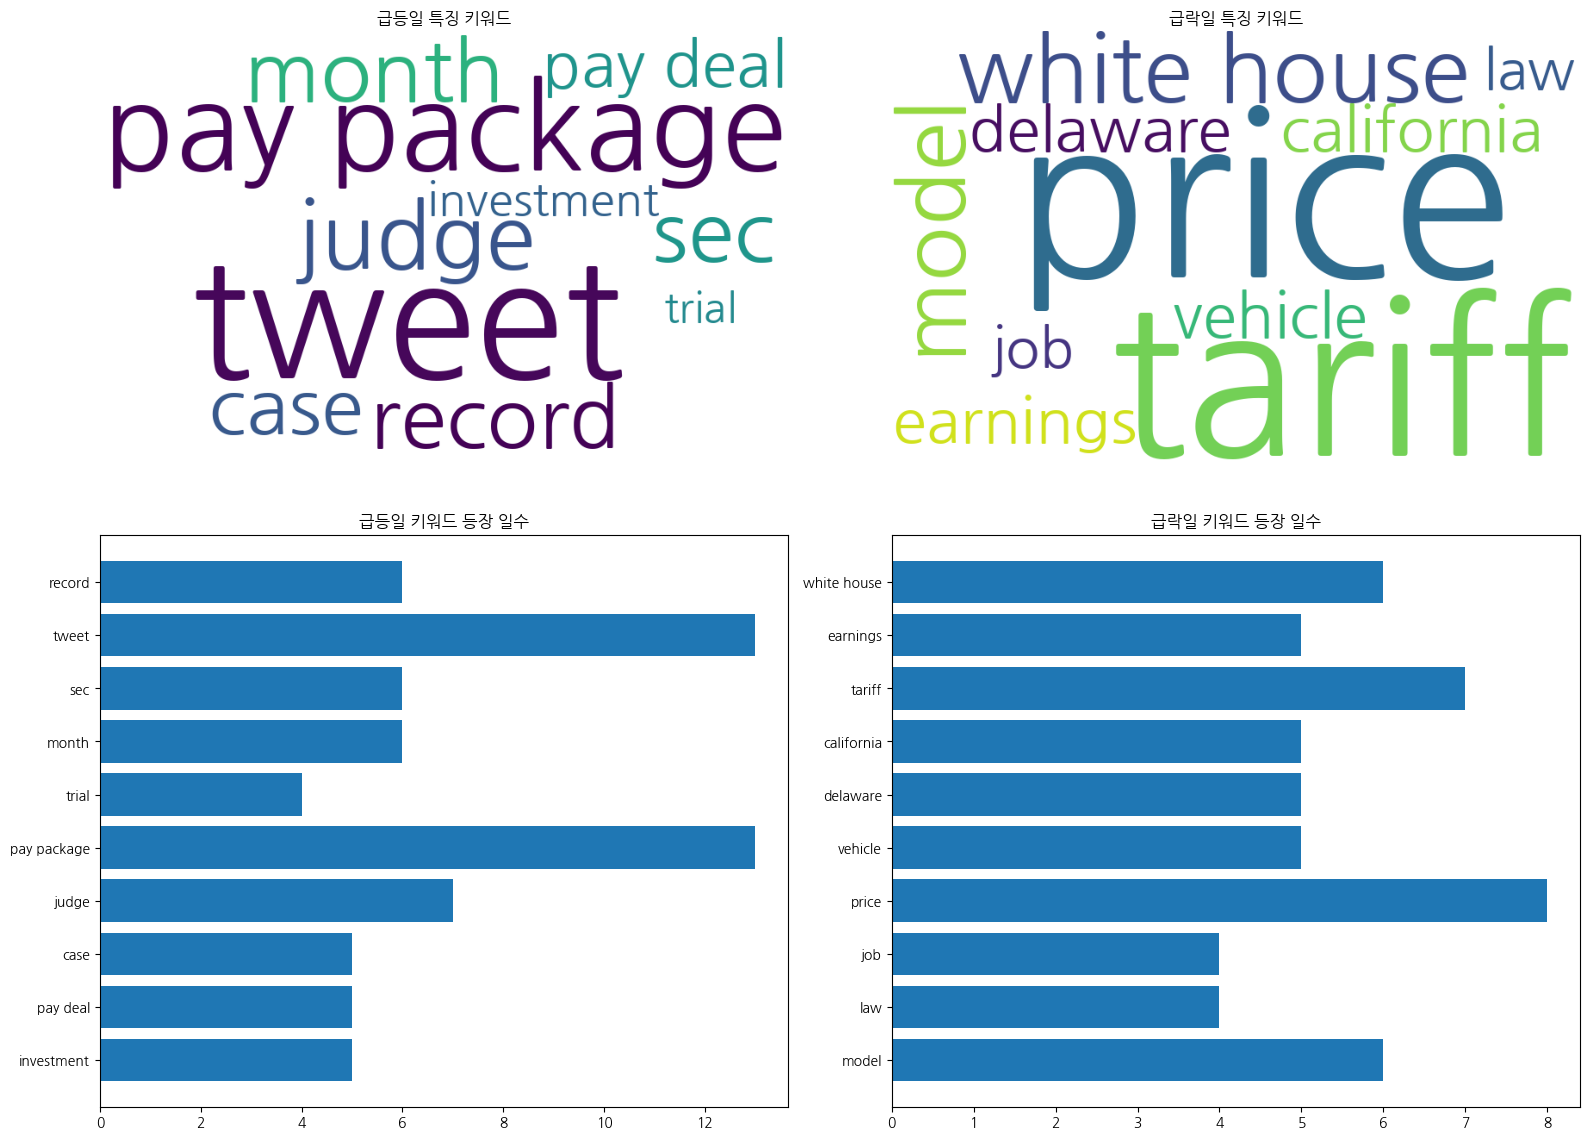

In [ ]:
surge_top = eda_terms_viz.sort_values(
    'surge_ratio',
    ascending=False
).head(10)

plunge_top = eda_terms_viz.sort_values(
    'surge_ratio',
    ascending=True
).head(10)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
wc1 = WordCloud(width=800,height=500,background_color='white',font_path=KOREAN_FONT).generate_from_frequencies(dict(zip(surge_top.term, surge_top.surge_days)))
wc2 = WordCloud(width=800,height=500,background_color='white',font_path=KOREAN_FONT).generate_from_frequencies(dict(zip(plunge_top.term, plunge_top.plunge_days)))
axes[0,0].imshow(wc1); axes[0,0].set_title('급등일 특징 키워드'); axes[0,0].axis('off')
axes[0,1].imshow(wc2); axes[0,1].set_title('급락일 특징 키워드'); axes[0,1].axis('off')
axes[1,0].barh(surge_top['term'][::-1], surge_top['surge_days'][::-1]); axes[1,0].set_title('급등일 키워드 등장 일수')
axes[1,1].barh(plunge_top['term'][::-1], plunge_top['plunge_days'][::-1]); axes[1,1].set_title('급락일 키워드 등장 일수')
plt.tight_layout(); plt.show()

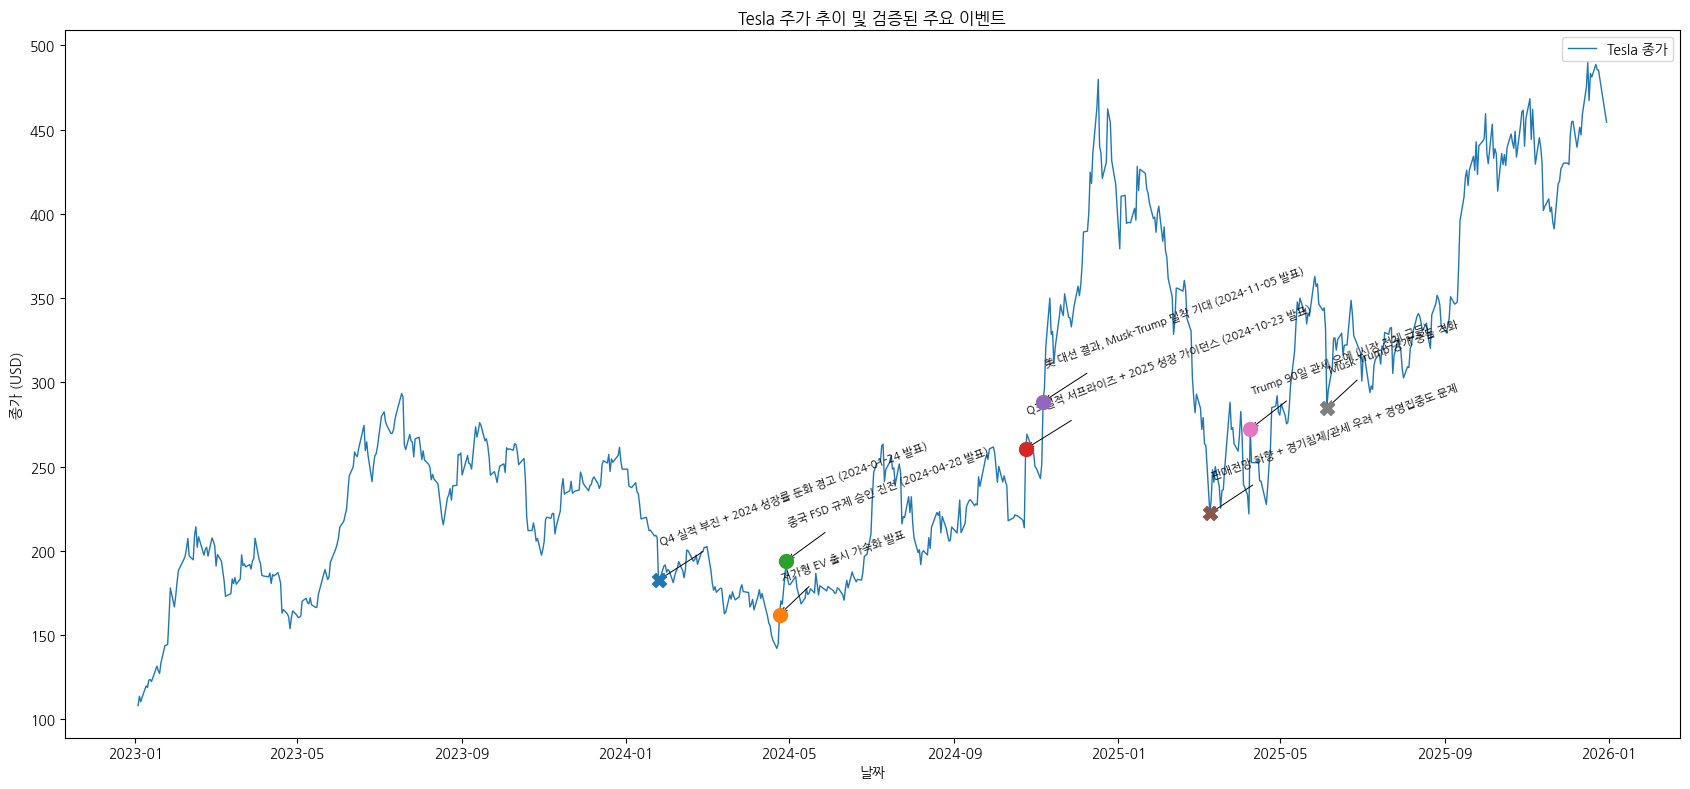

In [ ]:
ev = verified_events.merge(
    stock[['Date','Close']], left_on='Reaction_Date', right_on='Date', how='left'
)
fig, ax = plt.subplots(figsize=(17,8))
ax.plot(stock['Date'], stock['Close'], linewidth=1, label='Tesla 종가')
for _, row in ev.iterrows():
    marker = '^' if row['Category']=='매크로' else ('o' if row['Return_pct']>0 else 'X')
    ax.scatter(row['Reaction_Date'], row['Close'], s=100, marker=marker, zorder=5)
    note = f"{row['Event_Desc']} ({row['Trigger_Date'].date()} 발표)" if row['Timing_Gap_Days'] else row['Event_Desc']
    ax.annotate(note, xy=(row['Reaction_Date'], row['Close']), xytext=(0,25), textcoords='offset points', fontsize=8, rotation=20, arrowprops=dict(arrowstyle='->', lw=0.7))
ax.set_title('Tesla 주가 추이 및 검증된 주요 이벤트')
ax.set_xlabel('날짜'); ax.set_ylabel('종가 (USD)'); ax.legend(); plt.tight_layout(); plt.show()

## 7. 감성 분석 — FinBERT

FinBERT는 **자연어 원문 `Headline_clean**`에 적용한다. 감성 분석 결과는 두 가지 용도로 구분한다.

- EDA: 급등/급락/정상일의 감성 분포 비교
- ML: t일의 집계 감성 변수를 예측 feature로 사용

감성 분석 자체는 target을 사용하지 않으므로 전체 뉴스에 적용할 수 있지만, ML 모델의 성능 평가는 시간 순서로 분리한다.

In [ ]:
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1
finbert = pipeline(
    'sentiment-analysis',
    model='ProsusAI/finbert',
    device=device
)

texts = merged['Headline_clean'].fillna('').astype(str).tolist()
results = finbert(texts, batch_size=32, truncation=True, max_length=512)
merged['Sentiment_Label'] = [r['label'].lower() for r in results]
merged['Sentiment_Score'] = [float(r['score']) for r in results]

def signed_score(row):
    if row['Sentiment_Label'] == 'positive': return row['Sentiment_Score']
    if row['Sentiment_Label'] == 'negative': return -row['Sentiment_Score']
    return 0.0
merged['Signed_Sentiment'] = merged.apply(signed_score, axis=1)
print(merged['Sentiment_Label'].value_counts())

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Sentiment_Label
neutral     894
negative    492
positive    184
Name: count, dtype: int64


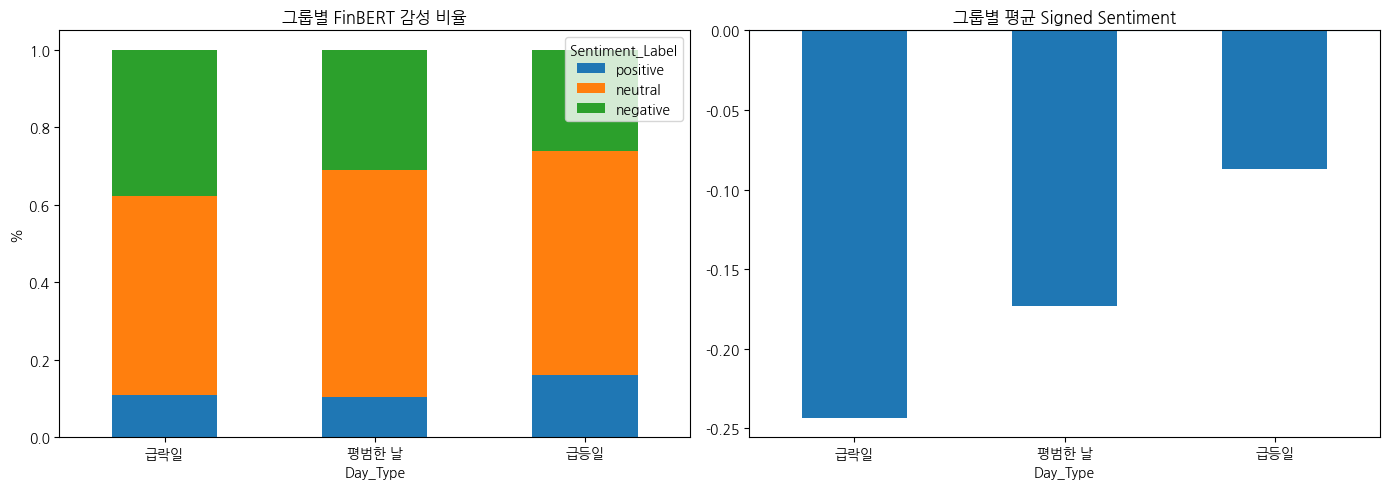

평균 Signed Sentiment


,Signed_Sentiment
Day_Type,
Plunge,-0.243422
Normal,-0.172909
Surge,-0.086902


In [ ]:
order = ['Plunge','Normal','Surge']
label_map = {'Plunge':'급락일','Normal':'평범한 날','Surge':'급등일'}
pct = merged.groupby('Day_Type')['Sentiment_Label'].value_counts(normalize=True).unstack().reindex(order)
avg_signed = merged.groupby('Day_Type')['Signed_Sentiment'].mean().reindex(order)

fig, axes = plt.subplots(1,2, figsize=(14,5))
pct[['positive','neutral','negative']].plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_xticklabels([label_map[x] for x in order], rotation=0); axes[0].set_ylabel('%'); axes[0].set_title('그룹별 FinBERT 감성 비율')
avg_signed.plot(kind='bar', ax=axes[1]); axes[1].axhline(0, linewidth=0.8); axes[1].set_xticklabels([label_map[x] for x in order], rotation=0); axes[1].set_title('그룹별 평균 Signed Sentiment')
plt.tight_layout(); plt.show()
print('평균 Signed Sentiment'); display(avg_signed)

## 8. 머신러닝 모델링

### 예측 정의

**Feature date = t**, **Target date = t+1 거래일**.  
t일 장 마감 후 계산 가능한 기술지표와 t일에 정렬된 뉴스 집계 정보를 Feature로 사용하여 다음 거래일 종가 방향을 예측한다.

뉴스에는 정확한 발행 시각이 없으므로 뉴스 Feature가 엄밀히 장 마감 이전에 이용 가능했다고 주장하지 않으며, 본 분석은 실시간/장중 예측 모델로 해석하지 않는다.

ML의 관측 단위는 feature date인 t 거래일이다.

Target은 t 거래일 종가 대비 t+1 거래일 종가의 상승/하락으로 정의한다.

따라서 최종 ML feature date는 2025-12-29이며,
해당 행의 Target 계산에는 2025-12-30 종가가 사용된다.
2025-12-30 자체는 새로운 feature date로 사용하지 않는다.

### 시간 분할

- Train: 최초 70%
- Validation: 다음 15%
- Test: 마지막 15%

Test 성능은 최종 모델과 Feature 조합이 확정된 뒤에만 평가한다.  
모델 및 Feature 선택은 Train/Validation 결과만을 사용한다..

In [ ]:
# 기술지표: 모두 t일 장 마감 후 계산 가능한 값
stock_ml = stock.copy()
stock_ml['MA5'] = stock_ml['Close'].rolling(5).mean()
stock_ml['MA10'] = stock_ml['Close'].rolling(10).mean()
stock_ml['Close_to_MA5'] = stock_ml['Close'] / stock_ml['MA5'] - 1
stock_ml['Close_to_MA10'] = stock_ml['Close'] / stock_ml['MA10'] - 1
stock_ml['Volatility_5d'] = stock_ml['Daily_Return'].rolling(5).std()
stock_ml['Volume_change_pct'] = stock_ml['Volume'].pct_change() * 100

# 뉴스: Reaction_Date를 feature date로 사용
# (EDA의 동시적 연관성 분석과 ML의 t→t+1 예측을 구분)
daily_news = merged.groupby('Reaction_Date').agg(
    article_count=('Headline_clean','count'),
    mean_sentiment=('Signed_Sentiment','mean'),
    positive_count=('Sentiment_Label', lambda x: (x=='positive').sum()),
    negative_count=('Sentiment_Label', lambda x: (x=='negative').sum()),
).reset_index().rename(columns={'Reaction_Date':'Date'})

df_ml = stock_ml.merge(daily_news, on='Date', how='left')
for c in ['article_count','positive_count','negative_count']:
    df_ml[c] = df_ml[c].fillna(0)
df_ml['mean_sentiment'] = df_ml['mean_sentiment'].fillna(0.0)

# Target의 마지막 행은 미래 수익률이 없으므로 명시적으로 제거
df_ml['Next_Return'] = df_ml['Close'].shift(-1) / df_ml['Close'] - 1
df_ml['Target'] = (df_ml['Next_Return'] > 0).astype(int)
df_ml = df_ml.dropna(subset=['Next_Return'] + ['MA5','MA10','Close_to_MA5','Close_to_MA10','Volatility_5d','Volume_change_pct']).reset_index(drop=True)

tech_features = ['Daily_Return_pct','Close_to_MA5','Close_to_MA10','Volatility_5d','Volume_change_pct']
news_features = ['article_count','mean_sentiment','positive_count','negative_count']

n = len(df_ml)
train_end = int(n*0.70)
val_end = int(n*0.85)
train = df_ml.iloc[:train_end].copy()
val = df_ml.iloc[train_end:val_end].copy()
test = df_ml.iloc[val_end:].copy()

print(f'Train: {len(train)} | Validation: {len(val)} | Test: {len(test)}')


Train: 518 | Validation: 111 | Test: 112


### 8-1. 베이스라인 및 모델 비교

Logistic Regression은 표준화가 필요한 모델이므로 `Pipeline(StandardScaler → LogisticRegression)`으로 구성한다.  
평가는 Accuracy 하나에 의존하지 않고 **Balanced Accuracy, Macro F1, ROC-AUC**를 함께 본다.

In [ ]:
def make_models():
    return {
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                max_iter=2000,
                random_state=42
            ))
        ]),

        'Random Forest': RandomForestClassifier(
            n_estimators=300,
            max_depth=5,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ),

        'XGBoost': XGBClassifier(
            n_estimators=250,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=42,
            n_jobs=2
        )
    }


def evaluate(model, X, y):

    pred = model.predict(X)

    proba = (
        model.predict_proba(X)[:, 1]
        if hasattr(model, 'predict_proba')
        else None
    )

    metrics = {
        'Accuracy':
            accuracy_score(y, pred),

        'Balanced_Accuracy':
            balanced_accuracy_score(y, pred),

        'Macro_F1':
            f1_score(
                y,
                pred,
                average='macro',
                zero_division=0
            ),

        'ROC_AUC':
            (
                roc_auc_score(y, proba)
                if proba is not None
                and y.nunique() == 2
                else np.nan
            )
    }

    return metrics, pred


# 비교할 Feature 조합
feature_sets = {
    '기술지표만':
        tech_features,

    '기술지표+뉴스감성':
        tech_features + news_features
}


# ============================================================
# Validation 결과만 계산
# Test는 여기서 사용하지 않음
# ============================================================

val_rows = []


for fs_name, feats in feature_sets.items():

    for model_name, model in make_models().items():

        # Train으로 학습
        model.fit(
            train[feats],
            train['Target']
        )

        # Validation으로만 평가
        val_metrics, _ = evaluate(
            model,
            val[feats],
            val['Target']
        )

        val_rows.append({
            'Feature_Set': fs_name,
            'Model': model_name,
            **val_metrics
        })


val_results = (
    pd.DataFrame(val_rows)
    .sort_values(
        'Balanced_Accuracy',
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    '===== VALIDATION RESULTS ====='
)

display(
    val_results
)

===== VALIDATION RESULTS =====


,Feature_Set,Model,Accuracy,Balanced_Accuracy,Macro_F1,ROC_AUC
0,기술지표만,XGBoost,0.567568,0.568182,0.565841,0.559091
1,기술지표만,Random Forest,0.513514,0.514448,0.508689,0.548701
2,기술지표+뉴스감성,XGBoost,0.513514,0.513961,0.512524,0.526623
3,기술지표+뉴스감성,Logistic Regression,0.513514,0.512987,0.511571,0.513961
4,기술지표+뉴스감성,Random Forest,0.504505,0.506169,0.487879,0.511364
5,기술지표만,Logistic Regression,0.486486,0.487175,0.483805,0.480844


### 8-2. 기본 Feature 조합의 Validation 1위 확인

기술지표와 뉴스 감성 Feature 조합에 대해
Validation Balanced Accuracy가 가장 높은 후보를 확인한다.

이 단계에서는 아직 Test 데이터를 평가하지 않는다.

이후 Train 기간에서만 선택한 Keyword Feature 실험까지 완료한 뒤,
모든 Validation 결과를 비교하여 최종 모델을 선택한다.

In [ ]:
# ============================================================
# 기본 Feature 조합에서 현재 Validation 1위 확인
# 아직 최종 모델 확정 아님
# Test 데이터도 사용하지 않음
# ============================================================

base_best_row = val_results.iloc[0]


print(
    '===== 현재 Validation 1위 ====='
)


print(
    'Model:',
    base_best_row['Model']
)


print(
    'Feature Set:',
    base_best_row['Feature_Set']
)


print(
    'Validation Balanced Accuracy:',
    round(
        base_best_row[
            'Balanced_Accuracy'
        ],
        4
    )
)


print(
    '\n※ 아직 Keyword Feature 실험이 남아 있으므로 '
    '최종 모델은 다음 단계 이후에 결정합니다.'
)

===== 현재 Validation 1위 =====
Model: XGBoost
Feature Set: 기술지표만
Validation Balanced Accuracy: 0.5682

※ 아직 Keyword Feature 실험이 남아 있으므로 최종 모델은 다음 단계 이후에 결정합니다.


### 8-3. 키워드 Feature — 학습기간에서만 선택

기존 방식처럼 전체 기간의 EDA 결과를 보고 수작업으로 고른 키워드를 Test Feature로 넣으면 feature selection leakage가 생길 수 있다.

따라서 아래에서는 **Train 기간의 뉴스와 Train 기간 안에서만 계산한 급등/급락 라벨(`Train_Day_Type`)을 이용해 카이제곱으로 키워드를 선택**한다.

선택된 키워드로 Train/Validation/Test의 일별 binary Feature를 생성하지만, Keyword 선택 과정에서는 Validation/Test의 Target을 사용하지 않는다.

In [ ]:
# ============================================================
# 8-3. Keyword Feature
# Keyword는 Train 기간에서만 선택
# 모델 성능 비교는 Validation까지만 수행
# Test는 아직 평가하지 않음
# ============================================================


# ============================================================
# Train 기간 안에서만 급등/급락 기준을 다시 계산
# ============================================================

train_end_date = train['Date'].max()


# Train 기간 주가 수익률만 사용
train_returns = stock.loc[
    stock['Date'] <= train_end_date,
    'Daily_Return_pct'
].dropna()


# Train 데이터 안에서만 하위 20%, 상위 20% 계산
train_q_low = train_returns.quantile(0.20)
train_q_high = train_returns.quantile(0.80)


print(
    f'Train 급락 기준: {train_q_low:.2f}% | '
    f'Train 급등 기준: {train_q_high:.2f}%'
)


# Train 기간 뉴스만 가져오기
train_eda = daily_text[
    daily_text['Reaction_Date'] <= train_end_date
].copy()


# Train 전용 Day Type 생성
def label_train_day(ret):

    if pd.isna(ret):
        return np.nan

    if ret >= train_q_high:
        return 'Surge'

    if ret <= train_q_low:
        return 'Plunge'

    return 'Normal'


train_eda['Train_Day_Type'] = (
    train_eda['Daily_Return_pct']
    .apply(label_train_day)
)


# Keyword 선택에는 Train 전용 급등/급락만 사용
train_eda = train_eda[
    train_eda['Train_Day_Type'].isin(
        ['Surge', 'Plunge']
    )
].copy()


# ------------------------------------------------------------
# 3. Train 기간 데이터만 이용해서 Keyword 후보 선택
# ------------------------------------------------------------

if len(train_eda) > 0:

    cv_kw = CountVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        binary=True
    )

    Xtr_kw = cv_kw.fit_transform(
        train_eda['text']
    )

    # Surge = 1, Plunge = 0
    ytr_kw = (
    train_eda['Train_Day_Type'] == 'Surge'
    ).astype(int).values


    # Chi-square 검정
    scores, pvals = chi2(
        Xtr_kw,
        ytr_kw
    )


    kw_df = pd.DataFrame({
        'term': cv_kw.get_feature_names_out(),
        'chi2': scores,
        'p_value': pvals
    })


    # FDR 보정
    kw_df['fdr_q'] = bh_fdr(
        kw_df['p_value'].values
    )


    # 우선 FDR 0.20 미만 Keyword 중 최대 10개 선택
    selected = (
        kw_df
        .sort_values(
            ['fdr_q', 'chi2'],
            ascending=[True, False]
        )
        .query('fdr_q < 0.20')
        .head(10)['term']
        .tolist()
    )


    # FDR 0.20 기준에서도 선택되는 Keyword가 없다면
    # Train 데이터에서 chi-square 값이 높은 10개 사용
    if len(selected) == 0:

        selected = (
            kw_df
            .sort_values(
                'chi2',
                ascending=False
            )
            .head(10)['term']
            .tolist()
        )

else:

    selected = []


print(
    'Train에서 선택된 keyword:',
    selected
)


# ------------------------------------------------------------
# 4. 선택된 Keyword를 날짜별 Feature로 만들기
#
# 예:
# kw_robotaxi = 그 날짜 뉴스에 robotaxi가 있으면 1
#               없으면 0
#
# 여기서는 Target을 사용하지 않음
# ------------------------------------------------------------

if selected:

    keyword_cols = {
        term: f'kw_{term.replace(" ", "_")}'
        for term in selected
    }


    merged_kw = merged.copy()

    merged_kw['Headline_lower'] = (
        merged_kw['Headline_final']
        .fillna('')
        .str.lower()
    )


    kw_daily = (
        merged_kw
        .groupby('Reaction_Date')
        .agg(
            **{
                col: (
                    'Headline_lower',
                    lambda s, term=term:
                    int(
                        s.str.contains(
                            re.escape(term),
                            regex=True
                        ).any()
                    )
                )
                for term, col
                in keyword_cols.items()
            }
        )
        .reset_index()
        .rename(
            columns={
                'Reaction_Date': 'Date'
            }
        )
    )

else:

    keyword_cols = {}


# ------------------------------------------------------------
# 5. Keyword 실험용 데이터셋을 따로 만들기
#
# 중요:
# 원래 df_ml은 건드리지 않음
# df_ml_kw라는 복사본에서만 Keyword를 추가함
# ------------------------------------------------------------

df_ml_kw = df_ml.copy()


if selected:

    df_ml_kw = df_ml_kw.merge(
        kw_daily,
        on='Date',
        how='left'
    )


    for c in keyword_cols.values():

        df_ml_kw[c] = (
            df_ml_kw[c]
            .fillna(0)
        )


# ------------------------------------------------------------
# 6. Keyword Feature 목록 만들기
# ------------------------------------------------------------

kw_features = list(
    keyword_cols.values()
)


# 기술지표 + 뉴스 감성 + Keyword
all_features = (
    tech_features
    + news_features
    + kw_features
)


# ------------------------------------------------------------
# 7. Keyword 실험용 데이터도
# 기존과 똑같은 Train / Validation / Test 위치로 분할
#
# 아직 Test 성능은 계산하지 않음
# ------------------------------------------------------------

train2 = df_ml_kw.iloc[
    :train_end
].copy()


val2 = df_ml_kw.iloc[
    train_end:val_end
].copy()


test2 = df_ml_kw.iloc[
    val_end:
].copy()


# ------------------------------------------------------------
# 8. Keyword Feature를 사용한 모델도
# Validation까지만 성능 비교
#
# Test는 여기서 절대 평가하지 않음
# ------------------------------------------------------------

keyword_rows = []


if len(kw_features) > 0:

    for model_name, model in make_models().items():

        # Train으로 학습
        model.fit(
            train2[all_features],
            train2['Target']
        )


        # Validation으로만 평가
        val_metrics, _ = evaluate(
            model,
            val2[all_features],
            val2['Target']
        )


        keyword_rows.append({

            'Feature_Set':
                '기술지표+뉴스감성+Train선택키워드',

            'Model':
                model_name,

            **val_metrics
        })


    keyword_results = (
        pd.DataFrame(keyword_rows)
        .sort_values(
            'Balanced_Accuracy',
            ascending=False
        )
        .reset_index(drop=True)
    )


    print(
        '\n===== KEYWORD FEATURE VALIDATION RESULTS ====='
    )

    display(
        keyword_results
    )


else:

    # Keyword가 하나도 없더라도
    # 다음 셀에서 오류가 나지 않도록 빈 표 생성
    keyword_results = pd.DataFrame(
        columns=val_results.columns
    )


    print(
        '\n선택된 Keyword가 없어 '
        'Keyword Feature 모델 비교를 생략합니다.'
    )



Train 급락 기준: -2.28% | Train 급등 기준: 2.90%
Train에서 선택된 keyword: ['tweet', 'wealth', 'man', 'medium', 'push', 'role', 'group', 'low', 'target', 'venture']

===== KEYWORD FEATURE VALIDATION RESULTS =====


,Feature_Set,Model,Accuracy,Balanced_Accuracy,Macro_F1,ROC_AUC
0,기술지표+뉴스감성+Train선택키워드,Random Forest,0.513514,0.514610,0.506748,0.518506
1,기술지표+뉴스감성+Train선택키워드,XGBoost,0.468468,0.468831,0.467777,0.515909
2,기술지표+뉴스감성+Train선택키워드,Logistic Regression,0.441441,0.441234,0.441033,0.470455


### 8-4. 최종 모델 선택 및 Test 평가

기본 Feature 조합과 Keyword Feature 조합의 **Validation Balanced Accuracy**를 함께 비교하여 최종 모델을 선택한다.

모델과 Feature 조합을 확정한 뒤에만 Test 데이터를 사용한다.

따라서 Test 결과는 모델 선택에 사용하지 않고, 최종 선택 모델의 일반화 성능을 확인하는 용도로만 사용한다.

Feature Importance는 모델이 예측 과정에서 각 변수를 상대적으로 얼마나 활용했는지를 보여주는 값이며, 인과관계를 의미하지 않는다.

===== ALL VALIDATION RESULTS =====


,Feature_Set,Model,Accuracy,Balanced_Accuracy,Macro_F1,ROC_AUC
0,기술지표만,XGBoost,0.567568,0.568182,0.565841,0.559091
1,기술지표+뉴스감성+Train선택키워드,Random Forest,0.513514,0.514610,0.506748,0.518506
2,기술지표만,Random Forest,0.513514,0.514448,0.508689,0.548701
3,기술지표+뉴스감성,XGBoost,0.513514,0.513961,0.512524,0.526623
4,기술지표+뉴스감성,Logistic Regression,0.513514,0.512987,0.511571,0.513961
5,기술지표+뉴스감성,Random Forest,0.504505,0.506169,0.487879,0.511364
6,기술지표만,Logistic Regression,0.486486,0.487175,0.483805,0.480844
7,기술지표+뉴스감성+Train선택키워드,XGBoost,0.468468,0.468831,0.467777,0.515909
8,기술지표+뉴스감성+Train선택키워드,Logistic Regression,0.441441,0.441234,0.441033,0.470455



===== FINAL MODEL SELECTION =====
Model: XGBoost
Feature Set: 기술지표만
Validation Balanced Accuracy: 0.5682

※ 여기까지 Test 성능은 모델 선택에 사용하지 않았습니다.

===== FINAL TEST RESULT =====


,Feature_Set,Model,Accuracy,Balanced_Accuracy,Macro_F1,ROC_AUC
0,기술지표만,XGBoost,0.491071,0.481356,0.47907,0.53359



===== TEST BASELINE =====


,Model,Accuracy,Balanced_Accuracy,Macro_F1,ROC_AUC
0,Majority Class Baseline,0.544643,0.5,0.352601,0.5



===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

          하락       0.43      0.37      0.40        51
          상승       0.53      0.59      0.56        61

    accuracy                           0.49       112
   macro avg       0.48      0.48      0.48       112
weighted avg       0.48      0.49      0.49       112



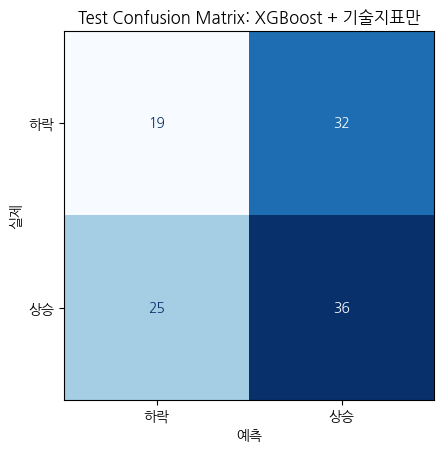


===== FEATURE IMPORTANCE =====


,Feature,Importance
0,Close_to_MA5,0.205371
1,Close_to_MA10,0.205029
2,Volume_change_pct,0.202307
3,Volatility_5d,0.197874
4,Daily_Return_pct,0.189420


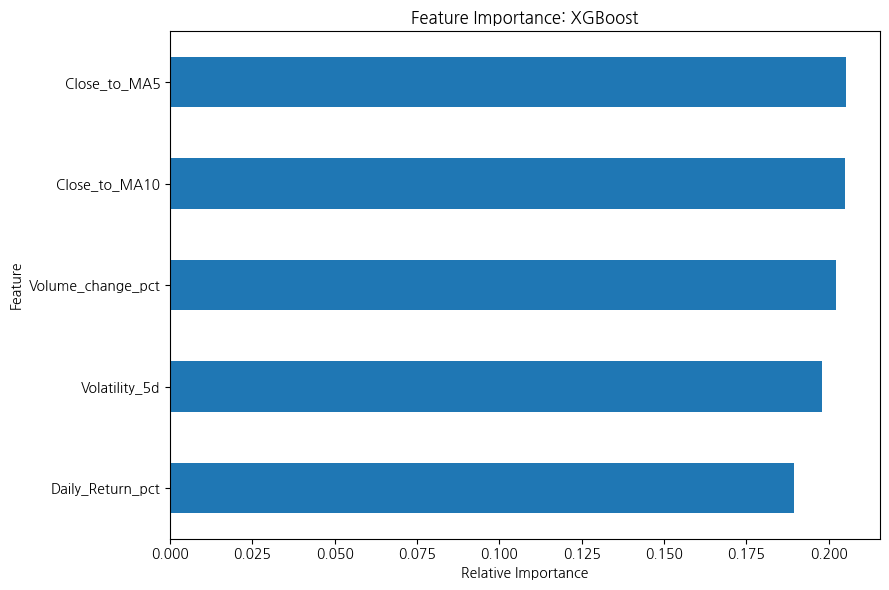

In [ ]:
# ============================================================
# 1. 모든 Validation 결과 합치기
# ============================================================

validation_tables = [
    val_results.copy()
]

if not keyword_results.empty:
    validation_tables.append(
        keyword_results.copy()
    )


all_val_results = pd.concat(
    validation_tables,
    ignore_index=True
).sort_values(
    'Balanced_Accuracy',
    ascending=False
).reset_index(drop=True)


print('===== ALL VALIDATION RESULTS =====')
display(all_val_results)


# ============================================================
# 2. Validation Balanced Accuracy 1위 선택
# ============================================================

best_row = all_val_results.iloc[0]

best_name = best_row['Model']
best_fs = best_row['Feature_Set']


# 어떤 Feature를 사용해야 하는지 결정
keyword_feature_set_name = (
    '기술지표+뉴스감성+Train선택키워드'
)


if best_fs == keyword_feature_set_name:

    best_feats = all_features

    final_train = train2
    final_test = test2

else:

    best_feats = feature_sets[best_fs]

    final_train = train
    final_test = test


print('\n===== FINAL MODEL SELECTION =====')

print(
    'Model:',
    best_name
)

print(
    'Feature Set:',
    best_fs
)

print(
    'Validation Balanced Accuracy:',
    round(
        best_row['Balanced_Accuracy'],
        4
    )
)

print(
    '\n※ 여기까지 Test 성능은 '
    '모델 선택에 사용하지 않았습니다.'
)


# ============================================================
# 3. 선택된 모델을 Train 데이터로 다시 학습
# ============================================================

best_model = make_models()[best_name]

best_model.fit(
    final_train[best_feats],
    final_train['Target']
)


# ============================================================
# 4. 이제 최종 선택 모델 하나만 Test 평가
# ============================================================

final_test_metrics, best_pred = evaluate(
    best_model,
    final_test[best_feats],
    final_test['Target']
)


final_test_results = pd.DataFrame([
    {
        'Feature_Set': best_fs,
        'Model': best_name,
        **final_test_metrics
    }
])


print('\n===== FINAL TEST RESULT =====')
display(final_test_results)


# ============================================================
# 5. 단순 다수 클래스 Baseline
# 모델 선택이 모두 끝난 뒤 Test에서 비교
# ============================================================

baseline = DummyClassifier(
    strategy='most_frequent'
)

baseline.fit(
    final_train[tech_features],
    final_train['Target']
)

base_metrics, baseline_pred = evaluate(
    baseline,
    final_test[tech_features],
    final_test['Target']
)


baseline_results = pd.DataFrame([
    {
        'Model': 'Majority Class Baseline',
        **base_metrics
    }
])


print('\n===== TEST BASELINE =====')
display(baseline_results)


# ============================================================
# 6. 최종 모델의 Classification Report
# ============================================================

print('\n===== CLASSIFICATION REPORT =====')

print(
    classification_report(
        final_test['Target'],
        best_pred,
        target_names=['하락', '상승'],
        zero_division=0
    )
)


# ============================================================
# 7. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    final_test['Target'],
    best_pred
)

ConfusionMatrixDisplay(
    cm,
    display_labels=['하락', '상승']
).plot(
    cmap='Blues',
    colorbar=False
)

plt.title(
    f'Test Confusion Matrix: '
    f'{best_name} + {best_fs}'
)

plt.xlabel('예측')
plt.ylabel('실제')

plt.show()


# ============================================================
# 8. Feature Importance
# ============================================================

if hasattr(
    best_model,
    'feature_importances_'
):

    importance_values = (
        best_model.feature_importances_
    )

elif (
    isinstance(best_model, Pipeline)
    and hasattr(
        best_model.named_steps['model'],
        'coef_'
    )
):

    # Logistic Regression이 선택될 경우
    # 표준화된 coefficient의 절댓값 사용
    importance_values = np.abs(
        best_model
        .named_steps['model']
        .coef_[0]
    )

    # 합이 1이 되도록 정규화
    if importance_values.sum() > 0:
        importance_values = (
            importance_values
            / importance_values.sum()
        )

else:

    importance_values = np.zeros(
        len(best_feats)
    )


feature_importance = pd.DataFrame({
    'Feature': best_feats,
    'Importance': importance_values
}).sort_values(
    'Importance',
    ascending=False
).reset_index(drop=True)


print('\n===== FEATURE IMPORTANCE =====')
display(feature_importance)


feature_importance.sort_values(
    'Importance'
).plot(
    kind='barh',
    x='Feature',
    y='Importance',
    figsize=(9, 6),
    legend=False
)

plt.title(
    f'Feature Importance: {best_name}'
)

plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()

plt.show()

## 9. 인사이트 및 결론

아래 결론은 고정된 과거 숫자를 복사하지 않고, **노트북을 실행한 결과에서 다시 계산**한다. 따라서 데이터/라이브러리 버전 변화에도 stale한 성능 수치를 남기지 않는다.

### 해석 원칙
- EDA의 키워드 차이 = **연관성**, 인과관계 아님
- FDR 보정 전후를 구분
- ML 성능은 Test 한 번의 수치만으로 일반화 가능성을 주장하지 않음
- 뉴스 feature 추가로 성능이 떨어져도 '뉴스가 무의미하다'고 단정하지 않음
- timestamp 부재와 작은 표본을 핵심 한계로 명시

In [ ]:
# ============================================================
# 실행 시점의 최종 결과 자동 요약
# ============================================================

print('===== 최종 요약 =====')


print(
    f'뉴스 원본: {len(news_raw):,}건 → '
    f'중복 제거 후: {len(news_dedup):,}건'
)


print(
    f'급등 기준: {q_high:.2f}% | '
    f'급락 기준: {q_low:.2f}%'
)


print(
    f'FDR 5% 유의 키워드 수: '
    f'{len(chi_sig)}'
)


print(
    f'Train / Validation / Test: '
    f'{len(train)} / '
    f'{len(val)} / '
    f'{len(test)}'
)


print('\n[최종 선택 모델]')

print(
    f'{best_name} / {best_fs}'
)


print(
    'Validation Balanced Accuracy:',
    round(
        best_row['Balanced_Accuracy'],
        4
    )
)


print('\n[최종 Test 성능]')

print(
    'Accuracy:',
    round(
        final_test_metrics['Accuracy'],
        4
    )
)

print(
    'Balanced Accuracy:',
    round(
        final_test_metrics[
            'Balanced_Accuracy'
        ],
        4
    )
)

print(
    'Macro F1:',
    round(
        final_test_metrics[
            'Macro_F1'
        ],
        4
    )
)

print(
    'ROC-AUC:',
    round(
        final_test_metrics[
            'ROC_AUC'
        ],
        4
    )
)


print('\n[Test Baseline]')

print(
    'Majority Class Accuracy:',
    round(
        base_metrics['Accuracy'],
        4
    )
)


print('\n[핵심 해석]')

print(
    '- EDA는 뉴스 키워드·감성과 '
    '주가 변동의 동시적 연관성을 탐색한다.'
)

print(
    '- 키워드 차이는 인과관계를 '
    '의미하지 않는다.'
)

print(
    '- ML은 t일 장 마감 정보를 이용해 '
    't+1 거래일 방향성을 예측한다.'
)

print(
    '- Keyword Feature는 Train 기간에서만 '
    '선택했다.'
)

print(
    '- 최종 모델은 Validation Balanced Accuracy '
    '기준으로 선택했다.'
)

print(
    '- Test는 최종 모델 선택이 끝난 뒤 '
    '일반화 성능 평가에만 사용했다.'
)

print(
    '- 뉴스 발행 timestamp가 없기 때문에 '
    '장중/장마감 이후 효과를 구분할 수 없다.'
)

print(
    '- Test 성능과 baseline을 함께 고려할 때 '
    '높은 일반화 예측력을 확보했다고 '
    '보기는 어렵다.'
)

===== 최종 요약 =====
뉴스 원본: 2,232건 → 중복 제거 후: 1,570건
급등 기준: 3.02% | 급락 기준: -2.36%
FDR 5% 유의 키워드 수: 0
Train / Validation / Test: 518 / 111 / 112

[최종 선택 모델]
XGBoost / 기술지표만
Validation Balanced Accuracy: 0.5682

[최종 Test 성능]
Accuracy: 0.4911
Balanced Accuracy: 0.4814
Macro F1: 0.4791
ROC-AUC: 0.5336

[Test Baseline]
Majority Class Accuracy: 0.5446

[핵심 해석]
- EDA는 뉴스 키워드·감성과 주가 변동의 동시적 연관성을 탐색한다.
- 키워드 차이는 인과관계를 의미하지 않는다.
- ML은 t일 장 마감 정보를 이용해 t+1 거래일 방향성을 예측한다.
- Keyword Feature는 Train 기간에서만 선택했다.
- 최종 모델은 Validation Balanced Accuracy 기준으로 선택했다.
- Test는 최종 모델 선택이 끝난 뒤 일반화 성능 평가에만 사용했다.
- 뉴스 발행 timestamp가 없기 때문에 장중/장마감 이후 효과를 구분할 수 없다.
- Test 성능과 baseline을 함께 고려할 때 높은 일반화 예측력을 확보했다고 보기는 어렵다.


### 검증 ###

In [ ]:
print("===== FINAL DATE CHECK =====")

print(
    "뉴스 마지막 날짜:",
    news_raw['Date'].max().date()
)

print(
    "주가 마지막 날짜:",
    stock['Date'].max().date()
)

print(
    "ML 마지막 feature 날짜:",
    df_ml['Date'].max().date()
)


assert (
    news_raw['Date'].max()
    == pd.Timestamp('2025-12-29')
)

assert (
    stock['Date'].max()
    == pd.Timestamp('2025-12-30')
)

assert (
    df_ml['Date'].max()
    == pd.Timestamp('2025-12-29')
)


print(
    "\n날짜 구조 확인 완료:"
)

print(
    "마지막 ML feature = 2025-12-29"
)

print(
    "그 다음 거래일 Target 계산용 주가 = 2025-12-30"
)

===== FINAL DATE CHECK =====
뉴스 마지막 날짜: 2025-12-29
주가 마지막 날짜: 2025-12-30
ML 마지막 feature 날짜: 2025-12-29

날짜 구조 확인 완료:
마지막 ML feature = 2025-12-29
그 다음 거래일 Target 계산용 주가 = 2025-12-30


In [ ]:
print("===== ML DATASET =====")

print("shape:", df_ml.shape)

print("\ncolumns:")
print(df_ml.columns.tolist())

print("\n결측치:")
display(df_ml.isna().sum())

print("\nTarget 분포:")
print(df_ml['Target'].value_counts())
print(df_ml['Target'].value_counts(normalize=True).round(4))

print("\n날짜 범위:")
print(df_ml['Date'].min(), "~", df_ml['Date'].max())

print("\n최근 데이터:")
display(
    df_ml[
        [
            'Date',
            'Close',
            'Daily_Return_pct',
            'Close_to_MA5',
            'Close_to_MA10',
            'Volatility_5d',
            'Volume_change_pct',
            'article_count',
            'mean_sentiment',
            'positive_count',
            'negative_count',
            'Next_Return',
            'Target'
        ]
    ].tail(10)
)

===== ML DATASET =====
shape: (741, 22)

columns:
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Prev_Close', 'Daily_Return', 'Daily_Return_pct', 'MA5', 'MA10', 'Close_to_MA5', 'Close_to_MA10', 'Volatility_5d', 'Volume_change_pct', 'article_count', 'mean_sentiment', 'positive_count', 'negative_count', 'Next_Return', 'Target']

결측치:


,0
Date,0
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0
Prev_Close,0
Daily_Return,0
Daily_Return_pct,0



Target 분포:
Target
1    384
0    357
Name: count, dtype: int64
Target
1    0.5182
0    0.4818
Name: proportion, dtype: float64

날짜 범위:
2023-01-17 00:00:00 ~ 2025-12-29 00:00:00

최근 데이터:


,Date,Close,Daily_Return_pct,Close_to_MA5,Close_to_MA10,Volatility_5d,Volume_change_pct,article_count,mean_sentiment,positive_count,negative_count,Next_Return,Target
731,2025-12-15,475.309998,3.562403,0.043362,0.055571,0.017334,19.742998,3.0,0.220969,1.0,0.0,0.030654,1
732,2025-12-16,489.880005,3.065369,0.054644,0.073472,0.018344,-6.053751,2.0,0.468131,1.0,0.0,-0.046175,0
733,2025-12-17,467.260010,-4.617456,-0.000855,0.019321,0.034994,-1.038676,1.0,0.943021,1.0,0.0,0.034478,1
734,2025-12-18,483.369995,3.447756,0.017715,0.047873,0.035099,-10.631944,3.0,-0.139239,1.0,2.0,-0.004489,0
735,2025-12-19,481.200012,-0.448928,0.003746,0.037277,0.035524,8.550107,0.0,0.000000,0.0,0.0,0.015648,1
736,2025-12-22,488.730011,1.564838,0.013778,0.042464,0.032955,-15.864902,3.0,0.055074,1.0,1.0,-0.006486,0
737,2025-12-23,485.559998,-0.648623,0.009010,0.026856,0.030075,-33.011720,3.0,-0.284378,0.0,1.0,-0.000330,0
738,2025-12-24,485.399994,-0.032952,0.001130,0.019200,0.017281,-29.091640,1.0,0.000000,0.0,0.0,-0.021034,0
739,2025-12-26,475.190002,-2.103418,-0.016610,-0.008132,0.013171,42.376482,3.0,0.000000,0.0,0.0,-0.032724,0
740,2025-12-29,459.640015,-3.272373,-0.040225,-0.040726,0.018686,12.729178,3.0,-0.313324,0.0,1.0,-0.011335,0


In [ ]:
print("===== TIME SPLIT =====")

for name, data in [('Train', train), ('Validation', val), ('Test', test)]:
    print(f"\n{name}:")
    print("  rows:", len(data))
    print("  date:", data['Date'].min(), "~", data['Date'].max())
    print("  target:", data['Target'].value_counts(normalize=True).round(4).to_dict())

print("\n===== SPLIT BOUNDARIES =====")
print("train_end:", train_end)
print("val_end:", val_end)

print("\n===== DATE OVERLAP CHECK =====")
print("Train ∩ Val:", len(set(train['Date']) & set(val['Date'])))
print("Train ∩ Test:", len(set(train['Date']) & set(test['Date'])))
print("Val ∩ Test:", len(set(val['Date']) & set(test['Date'])))

===== TIME SPLIT =====

Train:
  rows: 518
  date: 2023-01-17 00:00:00 ~ 2025-02-07 00:00:00
  target: {1: 0.5174, 0: 0.4826}

Validation:
  rows: 111
  date: 2025-02-10 00:00:00 ~ 2025-07-21 00:00:00
  target: {0: 0.5045, 1: 0.4955}

Test:
  rows: 112
  date: 2025-07-22 00:00:00 ~ 2025-12-29 00:00:00
  target: {1: 0.5446, 0: 0.4554}

===== SPLIT BOUNDARIES =====
train_end: 518
val_end: 629

===== DATE OVERLAP CHECK =====
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [ ]:
print(
    "===== ALL VALIDATION RESULTS ====="
)

display(
    all_val_results
)


print(
    "\n===== FINAL TEST RESULT ====="
)

display(
    final_test_results
)


print(
    "\n===== TEST BASELINE ====="
)

display(
    baseline_results
)

===== ALL VALIDATION RESULTS =====


,Feature_Set,Model,Accuracy,Balanced_Accuracy,Macro_F1,ROC_AUC
0,기술지표만,XGBoost,0.567568,0.568182,0.565841,0.559091
1,기술지표+뉴스감성+Train선택키워드,Random Forest,0.513514,0.514610,0.506748,0.518506
2,기술지표만,Random Forest,0.513514,0.514448,0.508689,0.548701
3,기술지표+뉴스감성,XGBoost,0.513514,0.513961,0.512524,0.526623
4,기술지표+뉴스감성,Logistic Regression,0.513514,0.512987,0.511571,0.513961
5,기술지표+뉴스감성,Random Forest,0.504505,0.506169,0.487879,0.511364
6,기술지표만,Logistic Regression,0.486486,0.487175,0.483805,0.480844
7,기술지표+뉴스감성+Train선택키워드,XGBoost,0.468468,0.468831,0.467777,0.515909
8,기술지표+뉴스감성+Train선택키워드,Logistic Regression,0.441441,0.441234,0.441033,0.470455



===== FINAL TEST RESULT =====


,Feature_Set,Model,Accuracy,Balanced_Accuracy,Macro_F1,ROC_AUC
0,기술지표만,XGBoost,0.491071,0.481356,0.47907,0.53359



===== TEST BASELINE =====


,Model,Accuracy,Balanced_Accuracy,Macro_F1,ROC_AUC
0,Majority Class Baseline,0.544643,0.5,0.352601,0.5


In [ ]:
print(
    "===== MODEL SELECTION ====="
)


print(
    "Validation 기준 상위 3개:"
)

display(
    all_val_results.head(3)
)


print(
    "\n최종 선택:"
)

print(
    "Model:",
    best_name
)

print(
    "Feature Set:",
    best_fs
)

print(
    "Validation Balanced Accuracy:",
    round(
        best_row[
            'Balanced_Accuracy'
        ],
        4
    )
)


print(
    "\n※ 모델 선택은 Validation 결과만 "
    "사용했습니다."
)

print(
    "※ Test 결과를 기준으로 "
    "모델 순위를 다시 매기지 않습니다."
)

===== MODEL SELECTION =====
Validation 기준 상위 3개:


,Feature_Set,Model,Accuracy,Balanced_Accuracy,Macro_F1,ROC_AUC
0,기술지표만,XGBoost,0.567568,0.568182,0.565841,0.559091
1,기술지표+뉴스감성+Train선택키워드,Random Forest,0.513514,0.514610,0.506748,0.518506
2,기술지표만,Random Forest,0.513514,0.514448,0.508689,0.548701



최종 선택:
Model: XGBoost
Feature Set: 기술지표만
Validation Balanced Accuracy: 0.5682

※ 모델 선택은 Validation 결과만 사용했습니다.
※ Test 결과를 기준으로 모델 순위를 다시 매기지 않습니다.


In [ ]:
print(
    "===== FINAL PIPELINE CHECK ====="
)


assert best_name == best_row['Model']

assert best_fs == best_row['Feature_Set']

assert len(best_pred) == len(final_test)


print(
    "모델 선택 정보: OK"
)

print(
    "Test prediction 길이: OK"
)

print(
    "최종 Test rows:",
    len(final_test)
)

===== FINAL PIPELINE CHECK =====
모델 선택 정보: OK
Test prediction 길이: OK
최종 Test rows: 112


In [ ]:
print(
    "===== SELECTED MODEL ====="
)


print(
    "best_name:",
    best_name
)

print(
    "best_fs:",
    best_fs
)


print(
    "\nSelected model:"
)

print(
    best_model
)


print(
    "\nSelected features:"
)

print(
    best_feats
)


print(
    "\nBest validation row:"
)

display(
    best_row.to_frame().T
)


print(
    "\nFinal Test prediction count:",
    len(best_pred)
)


print(
    "Final Test row count:",
    len(final_test)
)

===== SELECTED MODEL =====
best_name: XGBoost
best_fs: 기술지표만

Selected model:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=250, n_jobs=2,
              num_parallel_tree=None, ...)

Selected features:
['Daily_Return_pct', 'Close_to_MA5', 'Close_to_MA10', 'Volatility_5d', 'Volume_change_pct']

Best validation row:


,Feature_Set,Model,Accuracy,Balanced_Accuracy,Macro_F1,ROC_AUC
0,기술지표만,XGBoost,0.567568,0.568182,0.565841,0.559091



Final Test prediction count: 112
Final Test row count: 112


In [ ]:
print(
    "===== FINAL FEATURE IMPORTANCE ====="
)


display(
    feature_importance
)


print(
    "\nImportance 합계:",
    feature_importance[
        'Importance'
    ].sum()
)

===== FINAL FEATURE IMPORTANCE =====


,Feature,Importance
0,Close_to_MA5,0.205371
1,Close_to_MA10,0.205029
2,Volume_change_pct,0.202307
3,Volatility_5d,0.197874
4,Daily_Return_pct,0.189420



Importance 합계: 1.0


## 10. 최종 결과 파일 저장

검증이 완료된 ML 데이터셋, 최종 선택 모델, Feature Importance를
Streamlit 대시보드에서 사용할 수 있도록 파일로 저장한다.

- `df_ml_final.csv`: 최종 ML 데이터
- `selected_model.pkl`: Validation 기준으로 선정된 최종 모델
- `feature_importance.csv`: 최종 모델의 Feature Importance

In [ ]:
# ============================================================
# 최종 결과 파일 저장
# ============================================================

import joblib
import os


# 저장 위치
OUTPUT_DIR = '/content'


# ------------------------------------------------------------
# 1. 최종 ML 데이터 저장
# ------------------------------------------------------------

csv_path = os.path.join(
    OUTPUT_DIR,
    'df_ml_final.csv'
)

df_ml.to_csv(
    csv_path,
    index=False,
    encoding='utf-8-sig'
)


# ------------------------------------------------------------
# 2. 최종 선택 모델 저장
# ------------------------------------------------------------

model_path = os.path.join(
    OUTPUT_DIR,
    'selected_model.pkl'
)

joblib.dump(
    best_model,
    model_path
)


# ------------------------------------------------------------
# 3. Feature Importance 저장
# ------------------------------------------------------------

importance_path = os.path.join(
    OUTPUT_DIR,
    'feature_importance.csv'
)

feature_importance.to_csv(
    importance_path,
    index=False,
    encoding='utf-8-sig'
)


# ------------------------------------------------------------
# 저장 완료 확인
# ------------------------------------------------------------

print('===== FILE EXPORT COMPLETE =====')

print(
    'ML CSV:',
    csv_path
)

print(
    'Model PKL:',
    model_path
)

print(
    'Feature Importance CSV:',
    importance_path
)

===== FILE EXPORT COMPLETE =====
ML CSV: /content/df_ml_final.csv
Model PKL: /content/selected_model.pkl
Feature Importance CSV: /content/feature_importance.csv


In [ ]:
# ============================================================
# 저장된 파일 검증
# ============================================================

print('===== EXPORTED FILE CHECK =====')


# 파일 존재 여부
assert os.path.exists(csv_path)
assert os.path.exists(model_path)
assert os.path.exists(importance_path)


# ------------------------------------------------------------
# CSV 다시 불러오기
# ------------------------------------------------------------

df_ml_check = pd.read_csv(
    csv_path
)

print(
    'df_ml_final.csv shape:',
    df_ml_check.shape
)


# 원본과 행/열 개수가 같은지 확인
assert df_ml_check.shape == df_ml.shape


# ------------------------------------------------------------
# PKL 다시 불러오기
# ------------------------------------------------------------

loaded_model = joblib.load(
    model_path
)

print(
    'loaded model:',
    type(loaded_model).__name__
)


# ------------------------------------------------------------
# Feature Importance 다시 불러오기
# ------------------------------------------------------------

importance_check = pd.read_csv(
    importance_path
)

print(
    'feature_importance.csv shape:',
    importance_check.shape
)


assert (
    len(importance_check)
    == len(best_feats)
)


print(
    '\n모든 파일 저장 및 재로딩 검증 완료'
)

===== EXPORTED FILE CHECK =====
df_ml_final.csv shape: (741, 22)
loaded model: XGBClassifier
feature_importance.csv shape: (5, 2)

모든 파일 저장 및 재로딩 검증 완료


In [ ]:
# ============================================================
# 저장된 PKL 실제 prediction 검증
# ============================================================

sample_X = final_test[
    best_feats
].head(5)


sample_pred = loaded_model.predict(
    sample_X
)


print(
    '\nPKL sample prediction:',
    sample_pred
)


assert len(sample_pred) == 5


print(
    'PKL prediction test: OK'
)


PKL sample prediction: [0 1 0 1 0]
PKL prediction test: OK


In [ ]:
# ============================================================
# XGBoost 최종 모델을 공식 JSON 형식으로 저장
# ============================================================

best_model.save_model(
    '/content/selected_model.json'
)

print(
    'XGBoost model JSON 저장 완료'
)

XGBoost model JSON 저장 완료


In [ ]:
# ============================================================
# EDA 시각화용 Keyword 결과 저장
# ============================================================

surge_export = surge_top.copy()
surge_export['Direction'] = 'Surge'

plunge_export = plunge_top.copy()
plunge_export['Direction'] = 'Plunge'

keyword_summary = pd.concat(
    [
        surge_export,
        plunge_export
    ],
    ignore_index=True
)

keyword_summary.to_csv(
    '/content/eda_keyword_summary.csv',
    index=False,
    encoding='utf-8-sig'
)

print('EDA Keyword CSV 저장 완료')

display(
    keyword_summary[
        [
            'Direction',
            'term',
            'surge_days',
            'plunge_days',
            'surge_ratio'
        ]
    ]
)

EDA Keyword CSV 저장 완료


,Direction,term,surge_days,plunge_days,surge_ratio
0,Surge,record,6,1,0.851964
1,Surge,tweet,13,3,0.806069
2,Surge,sec,6,2,0.742105
3,Surge,month,6,3,0.657343
4,Surge,trial,4,2,0.657343
5,Surge,pay package,13,7,0.640461
6,Surge,judge,7,4,0.626667
7,Surge,case,5,3,0.615183
8,Surge,pay deal,5,3,0.615183
9,Surge,investment,5,3,0.615183


In [ ]:
# ============================================================
# FinBERT EDA 결과 저장
# ============================================================

# 1. 전체 뉴스 감성 분류 개수
sentiment_counts = (
    merged['Sentiment_Label']
    .value_counts()
    .rename_axis('Sentiment')
    .reset_index(name='Count')
)

sentiment_counts.to_csv(
    '/content/sentiment_counts.csv',
    index=False,
    encoding='utf-8-sig'
)


# 2. 급락 / 평범 / 급등일 평균 감성
sentiment_by_daytype = (
    merged
    .groupby('Day_Type')['Signed_Sentiment']
    .mean()
    .reindex(['Plunge', 'Normal', 'Surge'])
    .reset_index()
)

sentiment_by_daytype.columns = [
    'Day_Type',
    'Mean_Signed_Sentiment'
]

sentiment_by_daytype.to_csv(
    '/content/sentiment_by_daytype.csv',
    index=False,
    encoding='utf-8-sig'
)


print('FinBERT EDA CSV 저장 완료')

print('\n[Sentiment Counts]')
display(sentiment_counts)

print('\n[Sentiment by Day Type]')
display(sentiment_by_daytype)

FinBERT EDA CSV 저장 완료

[Sentiment Counts]


,Sentiment,Count
0,neutral,894
1,negative,492
2,positive,184



[Sentiment by Day Type]


,Day_Type,Mean_Signed_Sentiment
0,Plunge,-0.243422
1,Normal,-0.172909
2,Surge,-0.086902


===== 뉴스 Coverage 분석 =====


,항목,값
0,전체 거래일,750.00
1,뉴스가 있는 거래일,715.00
2,뉴스가 없는 거래일,35.00
3,뉴스 Coverage (%),95.33
4,뉴스 미존재 비율 (%),4.67
5,거래일당 평균 기사 수,2.09
6,뉴스가 있는 날의 평균 기사 수,2.20
7,거래일당 기사 수 중앙값,2.00
8,뉴스 0건 거래일,35.00
9,뉴스 1건 거래일,161.00


,구간,거래일 수
0,0건,35
1,1건,161
2,2건,253
3,3건 이상,301


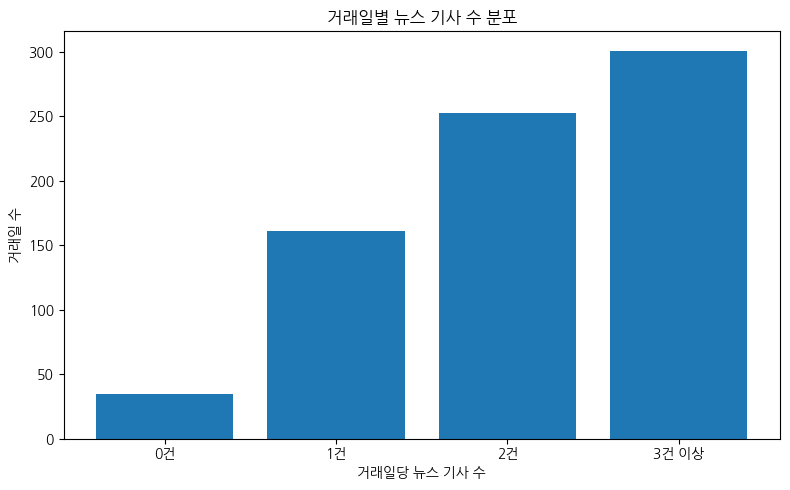


뉴스 Coverage CSV 저장 완료


In [ ]:
# ============================================================
# 뉴스 Coverage 분석
# 강사 피드백 반영:
# 거래일별 뉴스 데이터의 희소성 확인
# ============================================================

# 뉴스 데이터가 실제 존재하는 마지막 날짜까지만 사용
news_last_date = news_raw['Date'].max()

coverage_df = (
    stock.loc[
        stock['Date'] <= news_last_date,
        ['Date']
    ]
    .copy()
)

# 거래일 기준 일별 뉴스 집계와 결합
coverage_df = coverage_df.merge(
    daily_news[
        [
            'Date',
            'article_count'
        ]
    ],
    on='Date',
    how='left'
)

# 뉴스가 없는 거래일은 0건으로 처리
coverage_df['article_count'] = (
    coverage_df['article_count']
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 기본 Coverage 통계
# ------------------------------------------------------------

total_days = len(coverage_df)

days_with_news = (
    coverage_df['article_count'] > 0
).sum()

days_without_news = (
    coverage_df['article_count'] == 0
).sum()

coverage_rate = (
    days_with_news
    / total_days
    * 100
)

missing_rate = (
    days_without_news
    / total_days
    * 100
)

avg_articles_all_days = (
    coverage_df['article_count']
    .mean()
)

avg_articles_news_days = (
    coverage_df.loc[
        coverage_df['article_count'] > 0,
        'article_count'
    ]
    .mean()
)

median_articles = (
    coverage_df['article_count']
    .median()
)


# ------------------------------------------------------------
# 기사 수별 거래일 분류
# ------------------------------------------------------------

zero_news_days = (
    coverage_df['article_count'] == 0
).sum()

one_news_days = (
    coverage_df['article_count'] == 1
).sum()

two_news_days = (
    coverage_df['article_count'] == 2
).sum()

three_plus_news_days = (
    coverage_df['article_count'] >= 3
).sum()


# ------------------------------------------------------------
# 요약 표
# ------------------------------------------------------------

coverage_summary = pd.DataFrame({
    '항목': [
        '전체 거래일',
        '뉴스가 있는 거래일',
        '뉴스가 없는 거래일',
        '뉴스 Coverage (%)',
        '뉴스 미존재 비율 (%)',
        '거래일당 평균 기사 수',
        '뉴스가 있는 날의 평균 기사 수',
        '거래일당 기사 수 중앙값',
        '뉴스 0건 거래일',
        '뉴스 1건 거래일',
        '뉴스 2건 거래일',
        '뉴스 3건 이상 거래일'
    ],
    '값': [
        total_days,
        days_with_news,
        days_without_news,
        round(coverage_rate, 2),
        round(missing_rate, 2),
        round(avg_articles_all_days, 2),
        round(avg_articles_news_days, 2),
        round(median_articles, 2),
        zero_news_days,
        one_news_days,
        two_news_days,
        three_plus_news_days
    ]
})


print(
    '===== 뉴스 Coverage 분석 ====='
)

display(
    coverage_summary
)


# ------------------------------------------------------------
# 기사 수 분포
# ------------------------------------------------------------

coverage_distribution = pd.DataFrame({
    '구간': [
        '0건',
        '1건',
        '2건',
        '3건 이상'
    ],
    '거래일 수': [
        zero_news_days,
        one_news_days,
        two_news_days,
        three_plus_news_days
    ]
})

display(
    coverage_distribution
)


# ------------------------------------------------------------
# 간단한 시각화
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    coverage_distribution['구간'],
    coverage_distribution['거래일 수']
)

plt.title(
    '거래일별 뉴스 기사 수 분포'
)

plt.xlabel(
    '거래일당 뉴스 기사 수'
)

plt.ylabel(
    '거래일 수'
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Streamlit에서 나중에 사용할 CSV 저장
# ------------------------------------------------------------

coverage_df.to_csv(
    '/content/news_coverage_daily.csv',
    index=False,
    encoding='utf-8-sig'
)

coverage_summary.to_csv(
    '/content/news_coverage_summary.csv',
    index=False,
    encoding='utf-8-sig'
)

print(
    '\n뉴스 Coverage CSV 저장 완료'
)

===== 기간 단위 데이터 수 =====
일간: 750
주간: 157
월간: 36
분기: 12

===== 주간 데이터 =====


,Week,Start_Date,End_Date,Start_Close,End_Close,Trading_Days,Total_Volume,article_count,positive_count,negative_count,Period_Return_pct,Mean_Sentiment
147,2025-10-25/2025-10-31,2025-10-27,2025-10-31,452.420013,456.559998,5,409620400,11.0,1.0,5.0,0.915075,-0.312078
148,2025-11-01/2025-11-07,2025-11-03,2025-11-07,468.369995,429.519989,5,471019200,10.0,3.0,0.0,-8.294726,0.210947
149,2025-11-08/2025-11-14,2025-11-10,2025-11-14,445.230011,404.350006,5,420017300,10.0,1.0,3.0,-9.181772,-0.206784
150,2025-11-15/2025-11-21,2025-11-17,2025-11-21,408.920013,391.089996,5,468960000,8.0,1.0,3.0,-4.360270,-0.179632
151,2025-11-22/2025-11-28,2025-11-24,2025-11-28,417.779999,430.170013,4,268437900,10.0,4.0,2.0,2.965679,0.156637
152,2025-11-29/2025-12-05,2025-12-01,2025-12-05,430.140015,455.000000,5,342617200,10.0,1.0,4.0,5.779510,-0.219132
153,2025-12-06/2025-12-12,2025-12-08,2025-12-12,439.579987,458.959991,5,346426900,11.0,2.0,3.0,4.408755,-0.099660
154,2025-12-13/2025-12-19,2025-12-15,2025-12-19,475.309998,481.200012,5,527114500,9.0,4.0,2.0,1.239194,0.236053
155,2025-12-20/2025-12-26,2025-12-22,2025-12-26,488.730011,475.190002,4,245205800,10.0,1.0,2.0,-2.770448,-0.068791
156,2025-12-27/2026-01-02,2025-12-29,2025-12-29,459.640015,459.640015,1,66263000,3.0,0.0,1.0,0.000000,-0.313324



===== 월간 데이터 =====


,Month,Start_Date,End_Date,Start_Close,End_Close,Trading_Days,Total_Volume,article_count,positive_count,negative_count,Period_Return_pct,Mean_Sentiment
26,2025-03,2025-03-03,2025-03-31,284.649994,259.160004,21,2718957500,48.0,2.0,28.0,-8.954854,-0.467292
27,2025-04,2025-04-01,2025-04-30,268.459991,282.160004,21,2957985600,42.0,5.0,15.0,5.103186,-0.260132
28,2025-05,2025-05-01,2025-05-30,280.519989,346.459991,21,2195384900,41.0,7.0,9.0,23.506347,-0.035716
29,2025-06,2025-06-02,2025-06-30,342.690002,317.660004,20,2428761900,46.0,5.0,20.0,-7.303977,-0.278608
30,2025-07,2025-07-01,2025-07-31,300.709991,308.269989,22,2157408700,46.0,6.0,18.0,2.514049,-0.264672
31,2025-08,2025-08-01,2025-08-29,302.630005,333.869995,21,1603195500,45.0,5.0,15.0,10.322833,-0.208298
32,2025-09,2025-09-02,2025-09-30,329.359985,444.720001,21,1973602100,42.0,11.0,8.0,35.025510,0.065312
33,2025-10,2025-10-01,2025-10-31,459.459991,456.559998,23,2032095000,41.0,4.0,17.0,-0.631174,-0.244396
34,2025-11,2025-11-03,2025-11-28,468.369995,430.170013,19,1628434400,38.0,9.0,8.0,-8.155941,0.004499
35,2025-12,2025-12-01,2025-12-29,430.140015,459.640015,20,1527627400,43.0,8.0,12.0,6.858232,-0.064906



===== 분기 데이터 =====


,Quarter,Start_Date,End_Date,Start_Close,End_Close,Trading_Days,Total_Volume,article_count,positive_count,negative_count,Period_Return_pct,Mean_Sentiment
0,2023Q1,2023-01-03,2023-03-31,108.099998,207.460007,62,10833964400,127.0,14.0,37.0,91.914903,-0.154054
1,2023Q2,2023-04-03,2023-06-30,194.770004,261.769989,62,8630471700,131.0,12.0,36.0,34.399540,-0.159671
2,2023Q3,2023-07-03,2023-09-29,279.820007,250.220001,63,7335888800,137.0,16.0,29.0,-10.578231,-0.083457
3,2023Q4,2023-10-02,2023-12-29,251.600006,248.479996,63,7537585100,135.0,8.0,51.0,-1.240068,-0.266608
4,2024Q1,2024-01-02,2024-03-28,248.419998,175.789993,61,6263636300,127.0,7.0,45.0,-29.236779,-0.238171
5,2024Q2,2024-04-01,2024-06-28,175.220001,197.880005,63,5554648900,133.0,22.0,41.0,12.932316,-0.127951
6,2024Q3,2024-07-01,2024-09-30,209.860001,261.630005,64,6175635600,135.0,12.0,44.0,24.668829,-0.213324
7,2024Q4,2024-10-01,2024-12-31,258.019989,403.839996,64,5905625700,133.0,24.0,27.0,56.515004,-0.007573
8,2025Q1,2025-01-02,2025-03-31,379.279999,259.160004,60,5811328000,128.0,9.0,60.0,-31.670532,-0.341899
9,2025Q2,2025-04-01,2025-06-30,268.459991,317.660004,62,7582132400,129.0,17.0,44.0,18.326758,-0.195394



===== 기간별 탐색적 상관관계 =====


,기간,수익률-평균감성 상관계수,수익률-뉴스수 상관계수
0,주간,0.196460,0.025998
1,월간,0.483066,-0.004270
2,분기,0.505192,0.062711


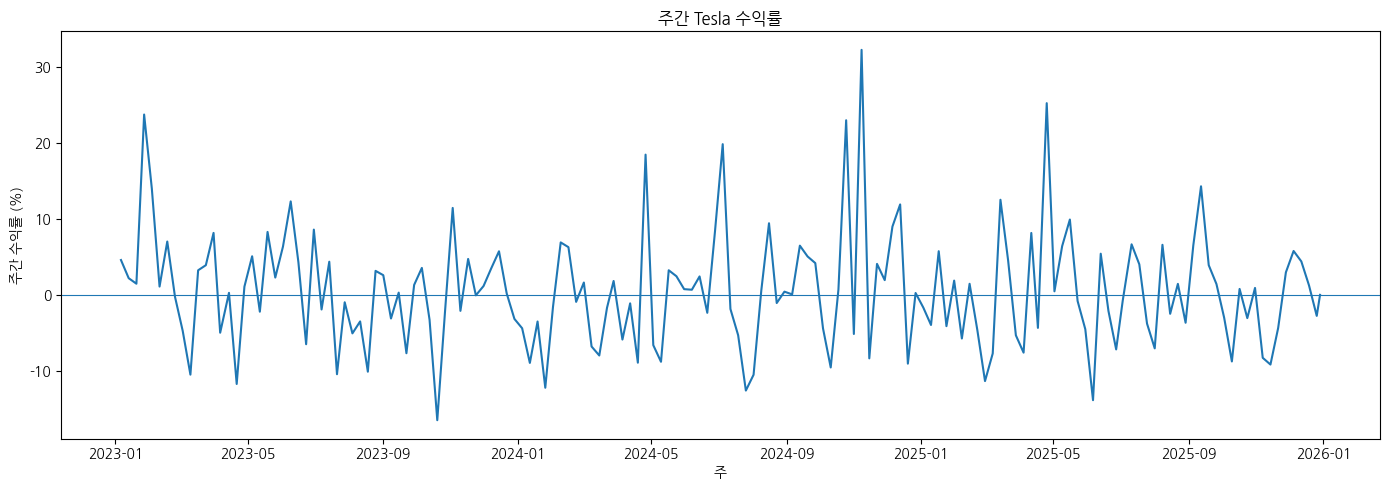

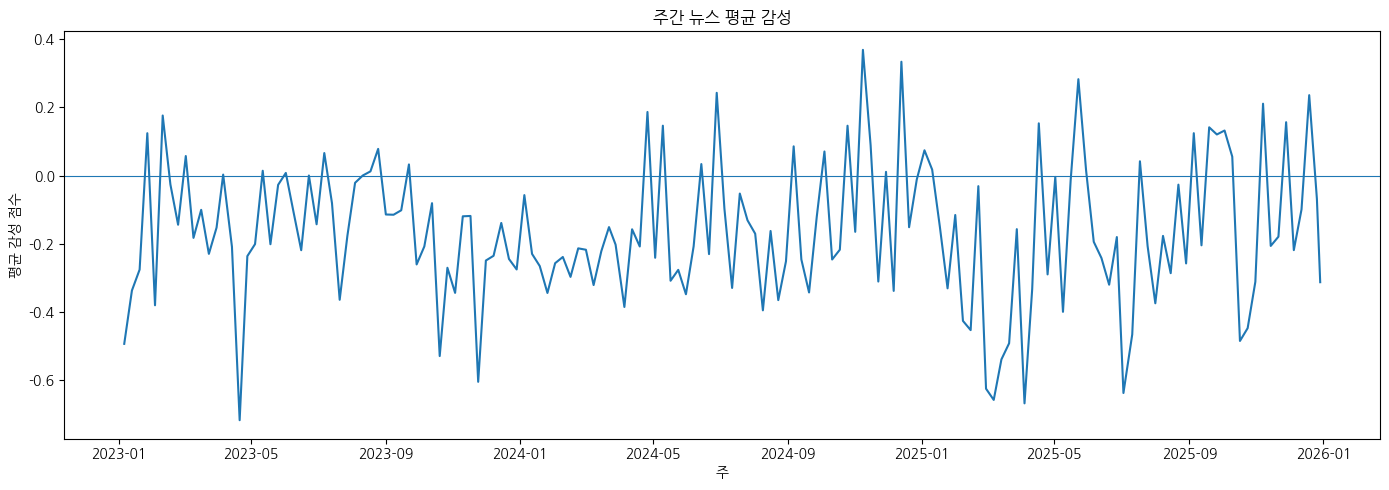

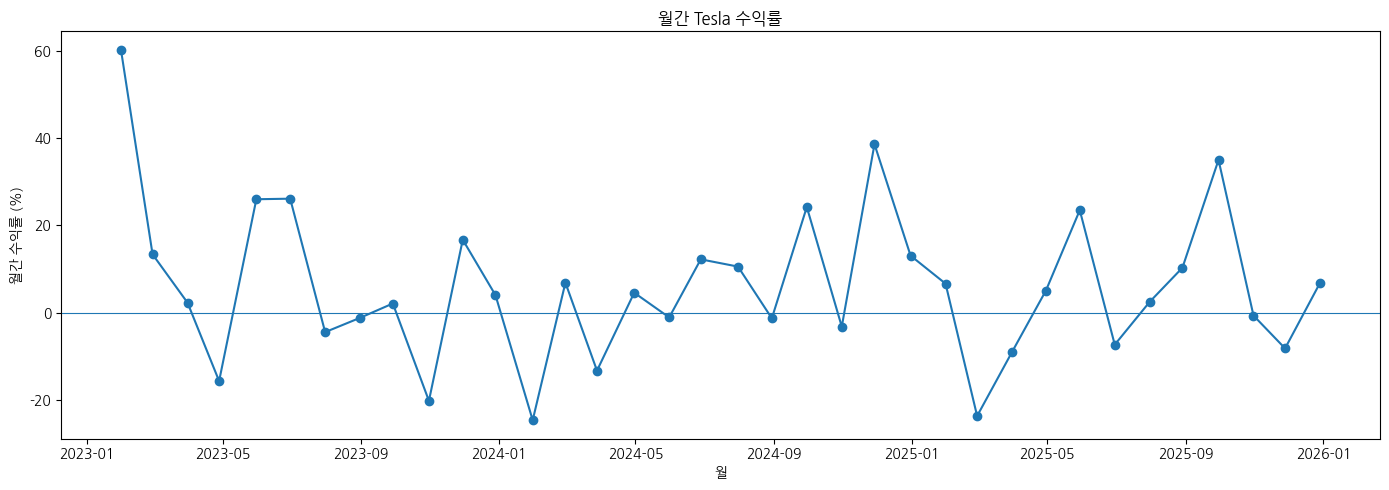

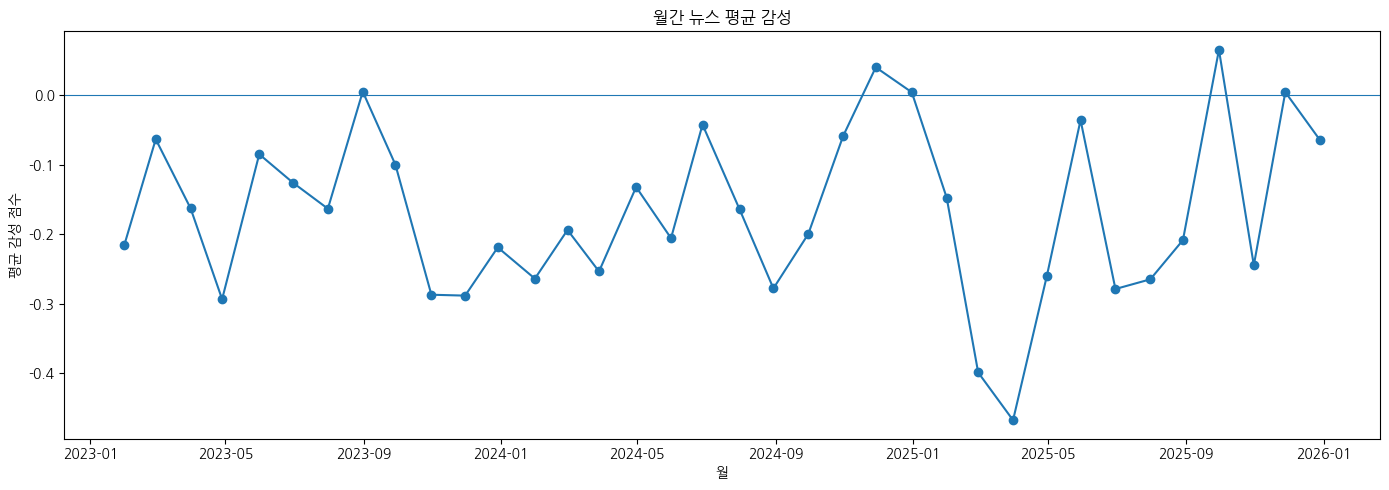


주간 / 월간 / 분기 EDA CSV 저장 완료


In [ ]:
# ============================================================
# 주간 / 월간 / 분기 단위 통합 EDA
# 강사 피드백 반영:
# 일별 데이터뿐 아니라 기간 단위로 통합하여 패턴 확인
# ============================================================

# 뉴스가 실제 존재하는 마지막 날짜까지만 사용
period_daily = (
    stock.loc[
        stock['Date'] <= news_last_date,
        [
            'Date',
            'Close',
            'Volume',
            'Daily_Return_pct'
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# 일별 뉴스 정보 결합
# ------------------------------------------------------------

period_daily = period_daily.merge(
    daily_news[
        [
            'Date',
            'article_count',
            'mean_sentiment',
            'positive_count',
            'negative_count'
        ]
    ],
    on='Date',
    how='left'
)


# 뉴스가 없는 거래일 처리
for col in [
    'article_count',
    'positive_count',
    'negative_count'
]:
    period_daily[col] = (
        period_daily[col]
        .fillna(0)
    )


period_daily['mean_sentiment'] = (
    period_daily['mean_sentiment']
    .fillna(0.0)
)


# ------------------------------------------------------------
# 기간 평균 감성을 정확히 계산하기 위한 가중합
#
# 예:
# 하루에 기사 1개인 날과 5개인 날을
# 동일한 비중으로 평균내지 않기 위해
# 기사 수를 반영한 가중 평균 사용
# ------------------------------------------------------------

period_daily[
    'sentiment_weighted_sum'
] = (
    period_daily['mean_sentiment']
    *
    period_daily['article_count']
)


# ------------------------------------------------------------
# 기간 구분 변수 생성
# ------------------------------------------------------------

period_daily['Week'] = (
    period_daily['Date']
    .dt.to_period('W-FRI')
)

period_daily['Month'] = (
    period_daily['Date']
    .dt.to_period('M')
)

period_daily['Quarter'] = (
    period_daily['Date']
    .dt.to_period('Q')
)


# ============================================================
# 기간 집계 함수
# ============================================================

def aggregate_period(data, period_col):

    result = (
        data
        .groupby(period_col)
        .agg(
            Start_Date=(
                'Date',
                'min'
            ),
            End_Date=(
                'Date',
                'max'
            ),
            Start_Close=(
                'Close',
                'first'
            ),
            End_Close=(
                'Close',
                'last'
            ),
            Trading_Days=(
                'Date',
                'size'
            ),
            Total_Volume=(
                'Volume',
                'sum'
            ),
            article_count=(
                'article_count',
                'sum'
            ),
            positive_count=(
                'positive_count',
                'sum'
            ),
            negative_count=(
                'negative_count',
                'sum'
            ),
            sentiment_weighted_sum=(
                'sentiment_weighted_sum',
                'sum'
            )
        )
        .reset_index()
    )


    # 기간 수익률:
    # 기간 첫 거래일 종가 → 마지막 거래일 종가
    result[
        'Period_Return_pct'
    ] = (
        (
            result['End_Close']
            /
            result['Start_Close']
        )
        - 1
    ) * 100


    # 기사 수를 반영한 평균 감성
    result[
        'Mean_Sentiment'
    ] = 0.0


    has_news = (
        result['article_count'] > 0
    )


    result.loc[
        has_news,
        'Mean_Sentiment'
    ] = (
        result.loc[
            has_news,
            'sentiment_weighted_sum'
        ]
        /
        result.loc[
            has_news,
            'article_count'
        ]
    )


    result = result.drop(
        columns=[
            'sentiment_weighted_sum'
        ]
    )


    return result


# ============================================================
# 주간 / 월간 / 분기 데이터 생성
# ============================================================

weekly_eda = aggregate_period(
    period_daily,
    'Week'
)

monthly_eda = aggregate_period(
    period_daily,
    'Month'
)

quarterly_eda = aggregate_period(
    period_daily,
    'Quarter'
)


# ============================================================
# 데이터 수 확인
# ============================================================

print(
    '===== 기간 단위 데이터 수 ====='
)

print(
    '일간:',
    len(period_daily)
)

print(
    '주간:',
    len(weekly_eda)
)

print(
    '월간:',
    len(monthly_eda)
)

print(
    '분기:',
    len(quarterly_eda)
)


# ============================================================
# 주간 결과 미리보기
# ============================================================

print(
    '\n===== 주간 데이터 ====='
)

display(
    weekly_eda.tail(10)
)


# ============================================================
# 월간 결과 미리보기
# ============================================================

print(
    '\n===== 월간 데이터 ====='
)

display(
    monthly_eda.tail(10)
)


# ============================================================
# 분기 결과
# ============================================================

print(
    '\n===== 분기 데이터 ====='
)

display(
    quarterly_eda
)


# ============================================================
# 기간별 상관관계
# 탐색적 결과이며 인과관계로 해석하지 않음
# ============================================================

period_correlations = pd.DataFrame({
    '기간': [
        '주간',
        '월간',
        '분기'
    ],

    '수익률-평균감성 상관계수': [
        weekly_eda[
            'Period_Return_pct'
        ].corr(
            weekly_eda[
                'Mean_Sentiment'
            ]
        ),

        monthly_eda[
            'Period_Return_pct'
        ].corr(
            monthly_eda[
                'Mean_Sentiment'
            ]
        ),

        quarterly_eda[
            'Period_Return_pct'
        ].corr(
            quarterly_eda[
                'Mean_Sentiment'
            ]
        )
    ],

    '수익률-뉴스수 상관계수': [
        weekly_eda[
            'Period_Return_pct'
        ].corr(
            weekly_eda[
                'article_count'
            ]
        ),

        monthly_eda[
            'Period_Return_pct'
        ].corr(
            monthly_eda[
                'article_count'
            ]
        ),

        quarterly_eda[
            'Period_Return_pct'
        ].corr(
            quarterly_eda[
                'article_count'
            ]
        )
    ]
})


print(
    '\n===== 기간별 탐색적 상관관계 ====='
)

display(
    period_correlations
)


# ============================================================
# 주간 시각화
# ============================================================

plt.figure(
    figsize=(14, 5)
)

plt.plot(
    weekly_eda[
        'End_Date'
    ],
    weekly_eda[
        'Period_Return_pct'
    ]
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.title(
    '주간 Tesla 수익률'
)

plt.xlabel(
    '주'
)

plt.ylabel(
    '주간 수익률 (%)'
)

plt.tight_layout()

plt.show()


plt.figure(
    figsize=(14, 5)
)

plt.plot(
    weekly_eda[
        'End_Date'
    ],
    weekly_eda[
        'Mean_Sentiment'
    ]
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.title(
    '주간 뉴스 평균 감성'
)

plt.xlabel(
    '주'
)

plt.ylabel(
    '평균 감성 점수'
)

plt.tight_layout()

plt.show()


# ============================================================
# 월간 시각화
# ============================================================

plt.figure(
    figsize=(14, 5)
)

plt.plot(
    monthly_eda[
        'End_Date'
    ],
    monthly_eda[
        'Period_Return_pct'
    ],
    marker='o'
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.title(
    '월간 Tesla 수익률'
)

plt.xlabel(
    '월'
)

plt.ylabel(
    '월간 수익률 (%)'
)

plt.tight_layout()

plt.show()


plt.figure(
    figsize=(14, 5)
)

plt.plot(
    monthly_eda[
        'End_Date'
    ],
    monthly_eda[
        'Mean_Sentiment'
    ],
    marker='o'
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.title(
    '월간 뉴스 평균 감성'
)

plt.xlabel(
    '월'
)

plt.ylabel(
    '평균 감성 점수'
)

plt.tight_layout()

plt.show()


# ============================================================
# Streamlit용 CSV 저장
# ============================================================

weekly_export = (
    weekly_eda
    .copy()
)

monthly_export = (
    monthly_eda
    .copy()
)

quarterly_export = (
    quarterly_eda
    .copy()
)


# Period 객체는 CSV에서 읽기 편하도록 문자열 변환
weekly_export[
    'Week'
] = (
    weekly_export[
        'Week'
    ].astype(str)
)

monthly_export[
    'Month'
] = (
    monthly_export[
        'Month'
    ].astype(str)
)

quarterly_export[
    'Quarter'
] = (
    quarterly_export[
        'Quarter'
    ].astype(str)
)


weekly_export.to_csv(
    '/content/weekly_eda.csv',
    index=False,
    encoding='utf-8-sig'
)

monthly_export.to_csv(
    '/content/monthly_eda.csv',
    index=False,
    encoding='utf-8-sig'
)

quarterly_export.to_csv(
    '/content/quarterly_eda.csv',
    index=False,
    encoding='utf-8-sig'
)


print(
    '\n주간 / 월간 / 분기 EDA CSV 저장 완료'
)

In [ ]:
# ============================================================
# Streamlit용 일간 EDA 데이터 저장
# ============================================================

daily_export = period_daily[
    [
        'Date',
        'Close',
        'Volume',
        'Daily_Return_pct',
        'article_count',
        'mean_sentiment',
        'positive_count',
        'negative_count'
    ]
].copy()

daily_export.to_csv(
    '/content/daily_eda.csv',
    index=False,
    encoding='utf-8-sig'
)

print('daily_eda.csv 저장 완료')
print('행 수:', len(daily_export))

display(
    daily_export.head()
)

daily_eda.csv 저장 완료
행 수: 750


,Date,Close,Volume,Daily_Return_pct,article_count,mean_sentiment,positive_count,negative_count
0,2023-01-03,108.099998,231402800,NaN,3.0,-0.323169,0.0,1.0
1,2023-01-04,113.639999,180389000,5.124885,2.0,-0.555663,0.0,2.0
2,2023-01-05,110.339996,157986300,-2.903910,2.0,-0.798547,0.0,2.0
3,2023-01-06,113.059998,220911100,2.465109,2.0,-0.385839,0.0,1.0
4,2023-01-09,119.769997,190284000,5.934901,3.0,-0.296594,0.0,1.0
